# Deep Image Restoration and Classification Pipeline

This notebook runs in dependency order so that **Run All** works from top to
bottom: setup, Phase 1 denoising, Phase 2 deblurring and evaluation, then
Phase 3 classification.


## 0. Environment Setup


In [2]:
import os
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from PIL import Image
from sklearn.metrics import confusion_matrix, f1_score
from torchvision import transforms


In [3]:
# Kaggle input and output paths used throughout the project
PROJECT_INPUT_DIR = "/kaggle/input/datasets/hamedpooraghniaei/image-processing-project"
DEBLUR_MODEL_DIR = "/kaggle/input/models/nguyenviettuankiet/deblur-single-blur-image/pytorch/default/11"

NOISY_IMAGE_PATH = f"{PROJECT_INPUT_DIR}/j45136_noisy_image_bird10.jpeg"
ORIGINAL_IMAGE_PATH = f"{PROJECT_INPUT_DIR}/z051867_bird.jpeg"
DENOISING_MODEL_PATH = f"{PROJECT_INPUT_DIR}/denoising_model.h5"

PHASE1_OUTPUT_PATH = "/kaggle/working/phase_1_results/phase1_denoised.jpg"
PHASE2_OUTPUT_DIR = "/kaggle/working/phase_2_results"

os.makedirs(os.path.dirname(PHASE1_OUTPUT_PATH), exist_ok=True)
os.makedirs(PHASE2_OUTPUT_DIR, exist_ok=True)
os.makedirs("/kaggle/working/models", exist_ok=True)
os.makedirs("/kaggle/working/data", exist_ok=True)

print("Project paths and output folders are ready.")


Project paths and output folders are ready.


## 1. Phase 1 - Denoising


### English Documentation

**Module:** Phase 1 - Deep Denoising Inference Execution (`denoising`)

**Objective:**

This function takes a heavily corrupted image containing Salt-and-Pepper noise and blur, passes it through a pre-trained Keras convolutional neural network, and outputs a cleaned intermediate image. This step removes the sharp point noise while preserving structural edges, preparing the image for the Phase 2 deblurring model.

**Inputs & Outputs:**

* **Inputs:**
* `image_path`: The file path to the raw, noisy, and blurred input image.
* `dest_path`: The destination file path where the denoised (but still blurry) output image will be saved.
* `model_path`: The file path to the saved TensorFlow/Keras model file (`.h5` or SavedModel format).


* **Output:** The function does not return a variable; it processes the image and writes the denoised result directly to the disk.

**How It Works (Mechanics):**

1. **Model Loading (Step 1):** It loads the pre-trained Keras model from disk using `tf.keras.models.load_model`. The argument `compile=False` is critical here; it instructs Keras to bypass looking for training configurations (like optimizers, legacy loss functions, or custom metrics), avoiding version compatibility errors and allowing pure inference.
2. **Color Space Conversion & Resizing (Step 2):** OpenCV loads images in **BGR** format by default. The function converts this to the standard **RGB** format because neural networks are trained on RGB data. It then resizes the image to $256 \times 256$ pixels to match the input layer dimensions expected by the pre-trained architecture.
3. **Data Type Normalization:** The pixel values are cast from 8-bit integers (`np.uint8`, range $[0, 255]$) to floating-point numbers (`np.float32`) and divided by $255.0$ to scale them to the range $[0.0, 1.0]$.
4. **Batch Dimension Expansion:** Keras models expect a 4D tensor input representing a "batch" of images: $(\text{Batch Size}, \text{Height}, \text{Width}, \text{Channels})$. Since we are processing a single image, `np.expand_dims` adds a leading dimension, converting the shape from $(256, 256, 3)$ to $(1, 256, 256, 3)$.
5. **Inference (Step 3):** The prepared tensor is passed through the model via `model.predict(input_tensor)` to generate the denoised output tensor.
6. **Postprocessing (Step 4):**
* `denoised_tensor[0]` extracts the first (and only) image from the batch.
* The values are multiplied by $255.0$ to scale them back to the standard $[0, 255]$ range.
* `np.clip(..., 0, 255)` acts as a guardrail, capping any floating-point anomalies that drift below $0$ or above $255$, before casting the data back to `np.uint8`.
* The color space is converted back to **BGR** so OpenCV's `cv2.imwrite` can save it with accurate colors.



---

### مستندات فارسی (Farsi Documentation)

**ماژول:** فاز اول - اجرای استنتاج برای حذف نویز (`denoising`)

**هدف:**

این تابع یک تصویر به شدت مخدوش‌شده (که حاوی نویز فلفل‌نمکی و تاری است) را دریافت کرده، آن را از یک شبکه عصبی کانولوشنی از پیش آموزش‌دیده در Keras عبور می‌دهد و خروجی تمیزشده‌ای را به عنوان تصویر میانی تولید می‌کند. این مرحله نویزهای نقطه‌ای تیز را حذف می‌کند در حالی که لبه‌های ساختاری تصویر را حفظ می‌کند تا تصویر برای مدل رفع تاری در فاز دوم آماده شود.

**ورودی‌ها و خروجی‌ها:**

* **ورودی‌ها:**
* `image_path`: مسیر تصویر ورودی که دارای نویز و تاری است.
* `dest_path`: مسیر ذخیره‌سازی تصویر خروجی که نویز آن حذف شده اما همچنان تار است.
* `model_path`: مسیر فایل مدل ذخیره شده تنسورفلو یا کراس (با فرمت `.h5` یا پوشه SavedModel).


* **خروجی:** این تابع متغیری برنمی‌گرداند؛ بلکه تصویر پردازش‌شده را مستقیماً روی حافظه ذخیره می‌کند.

**نحوه کار (مکانیسم‌ها):**
۱. **بارگذاری مدل (بخش 1):** مدل از پیش آموزش‌دیده را با استفاده از `tf.keras.models.load_model` بارگذاری می‌کند. استفاده از آرگومان `compile=False` در اینجا حیاتی است؛ این کار به کراس دستور می‌دهد که از بررسی تنظیمات مربوط به زمان آموزش (مانند بهینه‌سازها، توابع زیان قدیمی یا معیارهای ارزیابی سفارشی) چشم‌پوشی کند. این امر از خطاهای سازگاری نسخه‌ها جلوگیری کرده و امکان اجرای سریع استنتاج را فراهم می‌سازد.
۲. **تبدیل فضای رنگی و تغییر ابعاد (بخش 2):** کتابخانه OpenCV به صورت پیش‌فرض تصاویر را در قالب **BGR** بارگذاری می‌کند. این تابع تصویر را به فرمت استاندارد **RGB** تبدیل می‌کند زیرا شبکه‌های عصبی روی تصاویر RGB آموزش دیده‌اند. سپس اندازه تصویر را به $256 \times 256$ پیکسل تغییر می‌دهد تا با ابعاد لایه ورودی مورد انتظار شبکه سازگار شود.
۳. **نرمال‌سازی نوع داده:** مقادیر پیکسل‌ها از اعداد صحیح ۸ بیتی (`np.uint8` در بازه $[0, 255]$) به اعداد اعشاری (`np.float32`) تبدیل شده و بر عدد $255.0$ تقسیم می‌شوند تا مقادیر آن‌ها در بازه $[0.0, 1.0]$ قرار گیرد.
۴. **گسترش بعد دسته (Batch):** مدل‌های کراس انتظار یک تنسور ۴ بعدی به عنوان ورودی دارند که نشان‌دهنده یک «دسته» از تصاویر است: $(\text{Batch Size}, \text{Height}, \text{Width}, \text{Channels})$. از آنجایی که ما در حال پردازش یک تک تصویر هستیم، دستور `np.expand_dims` بعد اول را اضافه کرده و ابعاد تصویر را از $(256, 256, 3)$ به $(1, 256, 256, 3)$ تبدیل می‌کند.
۵. **استنتاج (بخش 3):** تنسور آماده‌شده از طریق متد `model.predict(input_tensor)` به مدل ارسال می‌شود تا تنسور خروجی بدون نویز تولید شود.
۶. **پس‌پردازش (بخش 4):**

* دستور `denoised_tensor[0]` اولین (و تنها) تصویر درون دسته را استخراج می‌کند.
* مقادیر در $255.0$ ضرب می‌شوند تا مقیاس آن‌ها مجدداً به بازه استاندارد $[0, 255]$ بازگردد.
* متد `np.clip(..., 0, 255)` به عنوان یک فیلتر محافظ عمل کرده و هرگونه مقدار اعشاری که خارج از بازه استاندارد قرار گرفته باشد را به مرزهای $0$ و $255$ محدود می‌کند و در نهایت نوع داده را مجدداً به `np.uint8` تبدیل می‌کند.
* فضای رنگی تصویر دوباره به **BGR** تبدیل می‌شود تا متد `cv2.imwrite` در OpenCV بتواند آن را با رنگ‌های صحیح ذخیره کند.

In [4]:
def denoising(image_path, dest_path, model_path):
    # 1. Load the downloaded model
    # Point this to your .h5 file or the unzipped SavedModel directory
    model = tf.keras.models.load_model(model_path, compile = False)

    # 2. Load and Preprocess the Noisy Image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # CRITICAL: Most Kaggle models expect a fixed input size (e.g., 256x256).
    # You might need to check the Kaggle page for the exact dimensions, but 256 is standard.
    image = cv2.resize(image, (256, 256))

    # Normalize the image (Neural networks usually expect values between 0.0 and 1.0)
    input_tensor = image.astype(np.float32) / 255.0

    # Add the batch dimension (shape becomes 1, 256, 256, 3)
    input_tensor = np.expand_dims(input_tensor, axis=0)

    # 3. Pass through the model
    denoised_tensor = model.predict(input_tensor)

    # 4. Postprocess and Save
    # Remove batch dimension and scale back to 0-255
    denoised_image = denoised_tensor[0] * 255.0
    denoised_image = np.clip(denoised_image, 0, 255).astype(np.uint8)

    # Convert back to BGR for OpenCV saving
    denoised_image = cv2.cvtColor(denoised_image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(dest_path, denoised_image)
    print("Denoised image saved successfully!")

In [5]:
import os

os.makedirs("/kaggle/working/phase_1_results", exist_ok=True)

denoising(
    image_path="/kaggle/input/datasets/hamedpooraghniaei/image-processing-project/j45136_noisy_image_bird10.jpeg",
    dest_path="/kaggle/working/phase_1_results/phase1_denoised.jpg",
    model_path="/kaggle/input/datasets/hamedpooraghniaei/image-processing-project/denoising_model.h5"
)

I0000 00:00:1784927390.164546      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784927390.167471      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Denoised image saved successfully!


I0000 00:00:1784927392.910711     137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


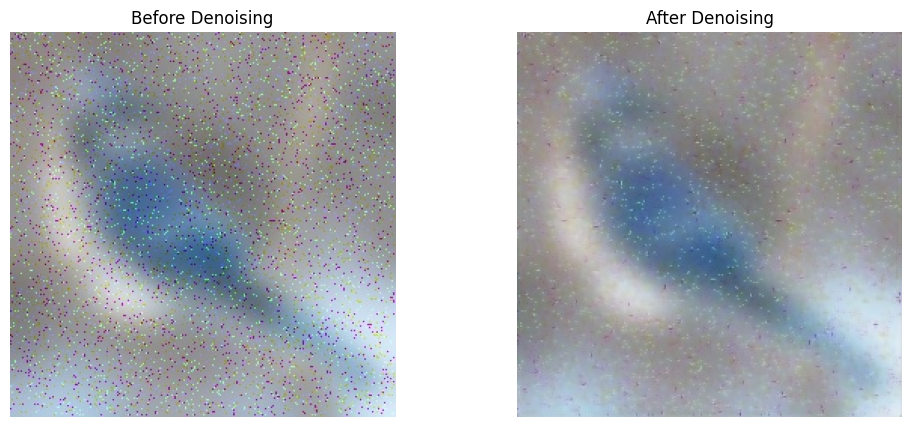

In [6]:
noisy = cv2.imread(
    "/kaggle/input/datasets/hamedpooraghniaei/image-processing-project/j45136_noisy_image_bird10.jpeg"
)

denoised = cv2.imread(
    "/kaggle/working/phase_1_results/phase1_denoised.jpg"
)

noisy = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)
denoised = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(noisy)
plt.title("Before Denoising")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(denoised)
plt.title("After Denoising")
plt.axis("off")

plt.show()

## 2. Phase 2 - Deblurring


### 2.1 Model Architectures


### English Documentation

**Module:** Architecture Definition - Residual CNN (`CNN`)

**Objective:**

This class defines the structural blueprint of a lightweight Convolutional Neural Network used for image restoration (denoising or deblurring). Instead of forcing the network to recreate a clean image from scratch, it utilizes **Global Residual Learning**. The model learns to predict only the degradation (the noise or blur) and then adds that prediction back to the corrupted input to recover the clean image.

**Inputs & Outputs:**

* **Inputs:** `x`, a 4D image tensor `(Batch, Channels, Height, Width)` containing the corrupted image.
* **Output:** `out`, a 4D tensor of the same shape containing the restored image, with its pixel values strictly clamped to the range [-1, 1].

**How It Works (Mechanics):**

1. **The Blueprint Inheritance:** The class inherits from `nn.Module`, which is the base class for all neural network modules in PyTorch. This allows the network to register its layers and parameters so PyTorch can track them during training.
2. **The Encoder:** The `self.encoder` block uses a sequence of three Convolutional layers with large 5x5 kernels. These larger kernels are specifically chosen to give the network a wider "receptive field," allowing it to look at a broader area of pixels to understand the structure of the blur or noise. `padding=2` ensures the image dimensions do not shrink as it passes through the layers.
3. **The Decoder:** The `self.decoder` block compresses the 64 feature maps extracted by the encoder back down to 3 standard color channels (RGB) using smaller 3x3 kernels. The output of this decoder is the **residual map** (the isolated noise/blur).
4. **Global Residual Connection (The `forward` pass):**
* `inp = x`: The original corrupted image is saved.
* `res = self.decoder(...)`: The network extracts the degradation map.
* `out = inp + res`: The extracted degradation is added to the original image to cancel out the corruption.


5. **Output Clamping:** The `.clamp(-1, 1)` function acts as a safety boundary. Because the model processes data normalized between -1 and 1 (as seen in your Phase 2 preprocessing), this ensures the final math operation doesn't push any pixel values out of the valid visual spectrum.

---

### مستندات فارسی (Farsi Documentation)

**ماژول:** تعریف معماری - شبکه عصبی پیچشی باقیمانده (`CNN`)

**هدف:**

این کلاس نقشه ساختاری یک شبکه عصبی پیچشی (CNN) سبک را برای بازیابی تصویر (حذف نویز یا رفع تاری) تعریف می‌کند. این مدل به جای اینکه تلاش کند یک تصویر تمیز را از صفر بازسازی کند، از روش **یادگیری باقیمانده سراسری (Global Residual Learning)** استفاده می‌کند. شبکه یاد می‌گیرد که تنها میزان خرابی (نویز یا تاری) را پیش‌بینی کند و سپس آن را به تصویر مخدوشِ ورودی اضافه می‌کند تا تصویر تمیز بازیابی شود.

**ورودی‌ها و خروجی‌ها:**

* **ورودی:** `x`، یک تنسور تصویر ۴ بعدی شامل `(دسته، کانال‌ها، ارتفاع، عرض)` که همان تصویر مخدوش است.
* **خروجی:** `out`، یک تنسور ۴ بعدی با همان ابعاد که حاوی تصویر بازیابی‌شده است و مقادیر پیکسل‌های آن دقیقاً در بازه [-۱, ۱] محدود شده‌اند.

**نحوه کار (مکانیسم‌ها):**
۱. **وراثت ساختاری:** این کلاس از `nn.Module` ارث‌بری می‌کند که کلاس پایه برای تمام ماژول‌های شبکه عصبی در پای‌تورچ است. این کار به شبکه اجازه می‌دهد تا لایه‌ها و پارامترهای خود را ثبت کند تا پای‌تورچ بتواند آن‌ها را در طول آموزش ردیابی کند.
۲. **رمزگذار (Encoder):** بلوک `self.encoder` از توالی سه لایه کانولوشنی با فیلترهای نسبتاً بزرگ 5x5 استفاده می‌کند. این فیلترهای بزرگ به‌طور خاص برای ایجاد "میدان دید" وسیع‌تر انتخاب شده‌اند تا شبکه بتواند ناحیه گسترده‌تری از پیکسل‌ها را بررسی کرده و ساختار تاری یا نویز را درک کند. مقدار `padding=2` تضمین می‌کند که ابعاد تصویر با عبور از این لایه‌ها کوچک نمی‌شود.
۳. **رمزگشا (Decoder):** بلوک `self.decoder` ۶۴ نقشه ویژگیِ (Feature Maps) استخراج‌شده توسط انکودر را با استفاده از فیلترهای کوچکتر 3x3 دوباره فشرده کرده و به ۳ کانال رنگی استاندارد (RGB) برمی‌گرداند. خروجی این دیکودر همان **نقشه باقیمانده** (نویز/تاریِ جدا شده) است.
۴. **اتصال باقیمانده سراسری (بخش `forward`):**

* `inp = x`: تصویر مخدوش اولیه ذخیره می‌شود.
* `res = self.decoder(...)`: شبکه نقشه خرابی را استخراج می‌کند.
* `out = inp + res`: خرابی استخراج‌شده به تصویر اصلی اضافه می‌شود تا اثر مخدوش‌کننده خنثی شود.
۵. **محدودسازی خروجی:** تابع `clamp(-1, 1).` به عنوان یک مرز ایمنی عمل می‌کند. از آنجا که مدل، داده‌های نرمال‌شده بین -۱ و ۱ را پردازش می‌کند (همان‌طور که در پیش‌پردازش فاز ۲ دیدیم)، این دستور تضمین می‌کند که عملیات ریاضیِ نهایی، مقدار هیچ پیکسلی را از طیف بصری معتبر خارج نکند.

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=2, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=5, padding=2, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=5, padding=2, bias=True),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, kernel_size=3, padding=1, bias=True)  # outputs residual
        )

    def forward(self, x):
        inp = x
        res = self.decoder(self.encoder(x))
        out = inp + res
        return out.clamp(-1, 1)

### English Documentation

**Module:** Architecture Definition - Advanced Residual Network (`ResBlock` & `ResNet`)

**Objective:**

This module defines a deeper, highly capable "hourglass-shaped" Convolutional Neural Network. Unlike the simple CNN, this model compresses the image to extract deep semantic features and then rebuilds it. It uses both **Local Residuals** (inside the blocks) and a **Global Residual** (at the very end) to achieve state-of-the-art image restoration without losing high-frequency details like sharp edges.

**Inputs & Outputs:**

* **Inputs:** `x`, a 4D image tensor `(Batch, Channels, Height, Width)` containing the blurred/noisy image.
* **Output:** `y`, a 4D tensor of the exact same shape containing the restored image, with its pixel values safely clamped to the range `[-1, 1]`.

**How It Works (Mechanics):**

1. **The `ResBlock` (Local Residuals):** This helper class creates a mini-network consisting of convolutions and normalizations. Crucially, the `forward` function calculates `x + self.block(x)`. This means the input skips the convolutional layers and is added directly to the output. This "shortcut" prevents the network from forgetting the original image details as it gets deeper (solving the Vanishing Gradient problem).
2. **Reflection Padding:** Instead of padding the edges of the image with black pixels (zeros), `nn.ReflectionPad2d` mirrors the edge pixels. This prevents the network from creating ugly, dark borders around the restored images.
3. **Downsampling (The Encoder):** The network uses `stride=2` convolutions to halve the image's width and height while doubling the number of feature channels (from 64 to 128 to 256). This forces the network to learn the "meaning" of the blur rather than just memorizing pixels.
4. **The Bottleneck:** The core of the network consists of a loop generating 9 consecutive `ResBlock` layers to deeply process the compressed features.
5. **Upsampling (The Decoder):** To get the image back to its original size, the network uses `nn.Upsample` with `mode='bilinear'` to stretch the feature maps, followed by a convolution to refine the details and halve the channels back down to 64.
6. **Kaiming Initialization (`_init`):** Instead of starting with random weights, the network uses `kaiming_normal_`. This mathematical initialization is specifically optimized for networks using `ReLU` activations, allowing the model to train much faster and more stably.

---

### مستندات فارسی (Farsi Documentation)

**ماژول:** تعریف معماری - شبکه پیشرفته باقیمانده (`ResBlock` و `ResNet`)

**هدف:**

این ماژول یک شبکه عصبی پیچشی (CNN) عمیق‌تر و بسیار توانمندتر با ساختار «ساعت‌شنی» را تعریف می‌کند. برخلاف CNN ساده، این مدل ابتدا تصویر را فشرده می‌کند تا ویژگی‌های معنایی عمیق آن را استخراج کند و سپس دوباره آن را بازسازی می‌نماید. این شبکه از ترکیب **باقیمانده‌های محلی (Local Residuals)** در داخل بلوک‌ها و یک **باقیمانده سراسری (Global Residual)** در انتهای شبکه استفاده می‌کند تا بالاترین کیفیت بازیابی تصویر را بدون از دست دادن جزئیات ظریف (مانند لبه‌های تیز) به دست آورد.

**ورودی‌ها و خروجی‌ها:**

* **ورودی:** `x`، یک تنسور تصویر ۴ بعدی شامل `(دسته، کانال‌ها، ارتفاع، عرض)` که همان تصویر تار یا نویزدار است.
* **خروجی:** `y`، یک تنسور ۴ بعدی با ابعاد دقیقاً یکسان حاوی تصویر بازیابی‌شده، که مقادیر پیکسل‌های آن در بازه ایمن `[-1, 1]` محدود شده‌اند.

**نحوه کار (مکانیسم‌ها):**
۱. **بلوک `ResBlock` (باقیمانده‌های محلی):** این کلاس کمکی، یک شبکه کوچک شامل لایه‌های کانولوشن و نرمال‌سازی ایجاد می‌کند. نکته حیاتی در تابع `forward` این است که `x + self.block(x)` محاسبه می‌شود. این یعنی ورودی، لایه‌های کانولوشن را دور زده و مستقیماً به خروجی اضافه می‌شود. این "مسیر میانبر" از فراموش شدن جزئیات تصویر اصلی در لایه‌های عمیق جلوگیری می‌کند (حل مشکل محو شدن گرادیان).
۲. **پدینگ انعکاسی (Reflection Padding):** به جای اینکه حاشیه‌های تصویر با پیکسل‌های سیاه (صفر) پر شوند، دستور `nn.ReflectionPad2d` پیکسل‌های لبه تصویر را مانند آینه منعکس می‌کند. این کار از ایجاد حاشیه‌های تیره و زشت در اطراف تصاویرِ بازیابی‌شده جلوگیری می‌کند.
۳. **کاهش ابعاد (رمزگذار یا Encoder):** شبکه از لایه‌های کانولوشن با `stride=2` استفاده می‌کند تا طول و عرض تصویر را نصف کند، در حالی که تعداد کانال‌های ویژگی را دو برابر می‌کند (از ۶۴ به ۱۲۸ و سپس ۲۵۶). این کار شبکه را مجبور می‌کند تا به جای حفظ کردن پیکسل‌ها، "مفهوم" و ساختار تاری را یاد بگیرد.
۴. **گلوگاه (Bottleneck):** هسته مرکزی شبکه از حلقه‌ای تشکیل شده است که ۹ لایه `ResBlock` متوالی را برای پردازش عمیقِ ویژگی‌های فشرده‌شده ایجاد می‌کند.
۵. **افزایش ابعاد (رمزگشا یا Decoder):** برای بازگرداندن تصویر به اندازه اصلی، شبکه از دستور `nn.Upsample` با متد `bilinear` (درونیابی دوخطی) برای کشیدن و بزرگ کردن نقشه‌های ویژگی استفاده می‌کند. سپس یک لایه کانولوشن اعمال می‌شود تا جزئیات را اصلاح کرده و کانال‌ها را دوباره به ۶۴ کاهش دهد.
۶. **مقداردهی اولیه کایمینگ (`_init`):** به جای شروع با وزن‌های کاملاً تصادفی، شبکه از متد `kaiming_normal_` استفاده می‌کند. این مقداردهی اولیهِ ریاضی، به‌طور خاص برای شبکه‌هایی که از تابع فعال‌ساز `ReLU` استفاده می‌کنند بهینه‌سازی شده است و به مدل اجازه می‌دهد بسیار سریع‌تر و پایدارتر آموزش ببیند.

In [8]:
class ResBlock(nn.Module):
    def __init__(self, c, norm='group'):
        super().__init__()
        Norm = {'instance': nn.InstanceNorm2d,
                'batch': nn.BatchNorm2d,
                'group': lambda ch: nn.GroupNorm(32 if ch >= 32 else 1, ch)}[norm]
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(c, c, 3, bias=False),
            Norm(c) if norm != 'group' else Norm(c),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(c, c, 3, bias=False),
            Norm(c) if norm != 'group' else Norm(c),
        )
    def forward(self, x): return x + self.block(x)

class ResNet(nn.Module):
    def __init__(self, input_nc=3, output_nc=3, num_resnet_blocks=9, norm='group'):
        super().__init__()
        Norm = {'instance': nn.InstanceNorm2d,
                'batch': nn.BatchNorm2d,
                'group': lambda ch: nn.GroupNorm(32 if ch >= 32 else 1, ch)}[norm]

        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_nc, 64, kernel_size=7, bias=False),
            Norm(64) if norm != 'group' else Norm(64),
            nn.ReLU(inplace=True)
        ]

        in_ch = 64
        for _ in range(2):
            out_ch = in_ch * 2
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
                Norm(out_ch) if norm != 'group' else Norm(out_ch),
                nn.ReLU(inplace=True)
            ]
            in_ch = out_ch

        for _ in range(num_resnet_blocks):
            layers += [ResBlock(in_ch, norm=norm)]

        for _ in range(2):
            out_ch = in_ch // 2
            layers += [
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                Norm(out_ch) if norm != 'group' else Norm(out_ch),
                nn.ReLU(inplace=True)
            ]
            in_ch = out_ch

        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, output_nc, kernel_size=7, bias=True)
        ]
        self.body = nn.Sequential(*layers)

        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        y = x + self.body(x)   # global residual
        return y.clamp(-1, 1)

### English Documentation

**Module:** Architecture Definition - Residual U-Net (`ConvBlock`, `Encoder`, `Decoder`, `UNet`)

**Objective:**

This module defines a U-Net, one of the most famous and powerful architectures in computer vision. Originally designed for medical image segmentation, this specific implementation is adapted for image restoration. It uses an "Encoder-Decoder" structure augmented with **Skip Connections** to capture both deep semantic context (what the blur/noise looks like) and precise spatial localization (exactly where the sharp edges should be). It concludes with a Global Residual connection to output the restored image.

**Inputs & Outputs:**

* **Inputs:** `inp`, a 4D image tensor `(Batch, Channels, Height, Width)` containing the corrupted image.
* **Output:** `y`, a 4D tensor of the same shape containing the restored image, with its pixel values safely clamped to `[-1, 1]`.

**How It Works (Mechanics):**

1. **`ConvBlock` (The Foundation):** A reusable block containing two convolutional layers, normalization (Group, Instance, or Batch), ReLU activations, and optional Dropout. This standardizes feature extraction across the entire network.
2. **`Encoder` (The Downward Path):** At each step, the encoder applies a `ConvBlock` to extract features, and then uses `nn.MaxPool2d(2)` to halve the spatial dimensions (width and height). Crucially, it returns *both* the pooled output (to go deeper) and the pre-pooled feature map (`feat`). This saved feature map is the secret to U-Net's success.
3. **`Decoder` (The Upward Path & Skip Connections):** The decoder doubles the spatial dimensions using `nn.Upsample`. It then takes the high-resolution feature map saved by the encoder (`x2`) and glues it together with the newly upsampled map (`x1_up`) using `torch.cat`. This "Skip Connection" feeds lost high-resolution details directly back into the network.
4. **Dimension Safety Net:** If the input image has an odd dimension (e.g., $33 \times 33$), max-pooling halves it to 16, and upsampling brings it back to 32. Since 32 does not equal 33, `torch.cat` would crash. The `F.interpolate` line in the decoder acts as a safety net, dynamically resizing the tensor to force a perfect match.
5. **`UNet` (The Assembly):** This chains 4 Encoders and 4 Decoders into a deep "U" shape. Finally, just like the ResNet, it applies a Global Residual connection (`y = inp + y`) so the network only has to learn the noise/blur rather than recreating the whole image from scratch.

---

### مستندات فارسی (Farsi Documentation)

**ماژول:** تعریف معماری - شبکه U-Net باقیمانده (`ConvBlock`, `Encoder`, `Decoder`, `UNet`)

**هدف:**

این ماژول یک U-Net را تعریف می‌کند که یکی از معروف‌ترین و قدرتمندترین معماری‌ها در بینایی ماشین است. این شبکه که در ابتدا برای بخش‌بندی (Segmentation) تصاویر پزشکی طراحی شده بود، در اینجا برای بازیابی تصویر تطبیق داده شده است. این مدل از ساختار "رمزگذار-رمزگشا" (Encoder-Decoder) تقویت‌شده با **اتصالات پرشی (Skip Connections)** استفاده می‌کند تا هم بافت معنایی عمیق (شکل تاری/نویز) و هم موقعیت مکانی دقیق (محل دقیق لبه‌های تیز) را درک کند. شبکه در نهایت با یک اتصال باقیمانده سراسری (Global Residual) تصویر بازسازی‌شده را تولید می‌کند.

**ورودی‌ها و خروجی‌ها:**

* **ورودی:** `inp`، یک تنسور تصویر ۴ بعدی `(دسته، کانال‌ها، ارتفاع، عرض)` حاوی تصویر مخدوش.
* **خروجی:** `y`، یک تنسور ۴ بعدی با ابعاد یکسان حاوی تصویر بازیابی‌شده، که مقادیر پیکسل‌های آن با ایمنی در بازه `[-1, 1]` محدود شده‌اند.

**نحوه کار (مکانیسم‌ها):**
۱. **`ConvBlock` (بلاک پایه):** یک بلوک با قابلیت استفاده مجدد که شامل دو لایه کانولوشن، نرمال‌سازی (Group، Instance یا Batch)، توابع فعال‌ساز ReLU و Dropout (اختیاری) است. این بلوک استخراج ویژگی‌ها را در سراسر شبکه استاندارد می‌کند.
۲. **`Encoder` (مسیر رو به پایین):** در هر مرحله، رمزگذار از یک `ConvBlock` برای استخراج ویژگی‌ها استفاده کرده و سپس با استفاده از `nn.MaxPool2d(2)` ابعاد مکانی (طول و عرض) را نصف می‌کند. نکته بسیار مهم این است که این کلاس *هم* خروجیِ کوچک‌شده (برای رفتن به لایه‌های عمیق‌تر) و *هم* نقشه ویژگیِ قبل از کوچک‌شدن (`feat`) را برمی‌گرداند. این نقشه ویژگی ذخیره‌شده، راز موفقیت معماری U-Net است.
۳. **`Decoder` (مسیر رو به بالا و اتصالات پرشی):** رمزگشا ابعاد مکانی را با استفاده از `nn.Upsample` دو برابر می‌کند. سپس نقشه ویژگی با وضوح بالا که توسط رمزگذار ذخیره شده بود (`x2`) را دریافت کرده و با استفاده از دستور `torch.cat` به نقشه جدیدِ بزرگ‌شده (`x1_up`) متصل می‌کند. این "اتصال پرشی" جزئیات از دست‌رفته با وضوح بالا را مستقیماً به شبکه بازمی‌گرداند.
۴. **محافظت از ابعاد:** اگر تصویر ورودی دارای ابعاد فرد باشد (مثلاً $33 \times 33$)، عملیات Max-pool آن را به ۱۶ کاهش داده و Upsample آن را به ۳۲ بازمی‌گرداند. از آنجا که ۳۲ با ۳۳ برابر نیست، دستور `torch.cat` دچار خطا می‌شود. خط `F.interpolate` در رمزگشا به عنوان یک شبکه ایمنی عمل کرده و اندازه تنسور را به صورت پویا تغییر می‌دهد تا تطابق کامل ایجاد شود.
۵. **`UNet` (مونتاژ نهایی):** این کلاس ۴ انکودر و ۴ دیکودر را به شکل یک "U" عمیق به هم متصل می‌کند. در نهایت، دقیقاً مانند شبکه ResNet، یک اتصال باقیمانده سراسری (`y = inp + y`) اعمال می‌شود تا شبکه به جای ساخت مجدد کل تصویر از صفر، تنها یاد بگیرد که نویز/تاری را پیش‌بینی کند.

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_dropout=False, norm='group'):
        super().__init__()
        if norm == 'instance':
            Norm = lambda c: nn.InstanceNorm2d(c, affine=True)
        elif norm == 'group':
            Norm = lambda c: nn.GroupNorm(32 if c >= 32 else 1, c)
        elif norm == 'batch':
            Norm = lambda c: nn.BatchNorm2d(c)
        else:
            raise ValueError(f"Unknown norm: {norm}")

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.n1 = Norm(out_ch)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.n2 = Norm(out_ch)
        self.relu2 = nn.ReLU(inplace=True)

        self.dropout = nn.Dropout2d(0.2) if use_dropout else nn.Identity()

    def forward(self, x):
        x = self.relu1(self.n1(self.conv1(x)))
        x = self.dropout(x)
        x = self.relu2(self.n2(self.conv2(x)))
        return x

class Encoder(nn.Module):
    def __init__(self, in_ch, out_ch, use_dropout=False, norm='group'):
        super().__init__()
        self.block = ConvBlock(in_ch, out_ch, use_dropout, norm=norm)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        feat = self.block(x)
        down = self.pool(feat)
        return feat, down

class Decoder(nn.Module):
    def __init__(self, up_in, skip_in, out_channels, use_dropout=False, norm='group'):
        super().__init__()
        self.upconv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(up_in, out_channels, 3, padding=1, bias=False)
        )
        self.conv = ConvBlock(out_channels + skip_in, out_channels, use_dropout, norm=norm)

    def forward(self, x1, x2):  # x1: deeper, x2: skip
        x1_up = self.upconv(x1)
        if x1_up.size()[2:] != x2.size()[2:]:
            x1_up = F.interpolate(x1_up, size=x2.size()[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x2, x1_up], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, use_dropout=False, norm='group', resize_output=False):
        super().__init__()
        self.resize_output = resize_output
        self.in_conv = ConvBlock(in_channels, 64, use_dropout, norm=norm)
        self.enc1 = Encoder(64, 128, use_dropout, norm=norm)
        self.enc2 = Encoder(128, 256, use_dropout, norm=norm)
        self.enc3 = Encoder(256, 512, use_dropout, norm=norm)
        self.enc4 = Encoder(512, 1024, use_dropout, norm=norm)

        self.dec1 = Decoder(1024, 512, 512, use_dropout, norm=norm)
        self.dec2 = Decoder(512, 256, 256, use_dropout, norm=norm)
        self.dec3 = Decoder(256, 128, 128, use_dropout, norm=norm)
        self.dec4 = Decoder(128, 64, 64, use_dropout, norm=norm)

        self.out_conv = nn.Conv2d(64, out_channels, 1)

    def forward(self, inp, target_size=None):
        x1 = self.in_conv(inp)             # H, W
        f2, x2 = self.enc1(x1)             # f2: H/1, x2: H/2
        f3, x3 = self.enc2(x2)             # f3: H/2, x3: H/4
        f4, x4 = self.enc3(x3)             # f4: H/4, x4: H/8
        f5, x5 = self.enc4(x4)             # f5: H/8, x5: H/16

        x = self.dec1(x5, f4)
        x = self.dec2(x, f3)
        x = self.dec3(x, f2)
        x = self.dec4(x, x1)

        y = self.out_conv(x)
        y = inp + y                         # global residual
        if self.resize_output:
            target_size = target_size or x1.shape[2:]
            y = F.interpolate(y, size=target_size, mode='bilinear', align_corners=False)
        return y.clamp(-1, 1)

### 2.2 Shared Deblurring Inference Function


**Module:** Phase 2 - Deblurring Inference Execution (`apply_deblur_model`)

**Objective:**
This function takes the intermediate image from Phase 1 (which has been denoised but is still blurry), processes it through a pre-trained deep learning architecture, and outputs a sharp, fully restored image ready for classification.

**Inputs & Outputs:**

* **Inputs:**
* `model_path`: The file path to the saved `.pth` checkpoint containing the pre-trained weights.
* `input_path`: The file path to the blurry image (the output from Phase 1).
* `destination_path`: The file path where the final sharp image will be saved.
* `model_name`: A string (e.g., "resnet", "unet", "DiffCNN") dictating which network architecture blueprint to load.


* **Output:** The function does not return a variable; it saves the restored image directly to the disk.

**How It Works (Mechanics):**

1. **Device Configuration:** It automatically detects if a GPU (`cuda`) is available to speed up processing; otherwise, it defaults to the CPU.
2. **Architecture Initialization (Step A):** Before weights can be loaded, the structural "blueprint" of the model must be created. The function dynamically selects the correct architecture based on the `model_name` argument.
3. **Weight Loading (Steps B & C):** It loads the `model_state` (the learned parameters/weights) from the checkpoint file into the empty blueprint.
4. **Evaluation State (Step D):** Calling `model.eval()` is a critical step that locks the model, disabling layers like Dropout and Batch Normalization that are only meant for active training.
5. **Preprocessing (Step E):** The image is converted into a PyTorch Tensor and normalized. The normalization transforms the pixel range from $[0, 1]$ to $[-1, 1]$, which is required for this specific model to function correctly. The `.unsqueeze(0)` command adds a "batch" dimension because neural networks expect a batch of images, even if the batch size is just 1.
6. **Inference:** `torch.no_grad()` is used to pass the image through the network. This tells PyTorch not to calculate gradients, saving massive amounts of memory and time.
7. **Postprocessing (Step F):** The output tensor is un-normalized (shifted back to $[0, 1]$), clamped to ensure no pixel values exceed standard boundaries, converted back into a standard image, and saved.

---

### مستندات فارسی (Farsi Documentation)

**ماژول:** فاز دوم - اجرای استنتاج برای رفع تاری (`apply_deblur_model`)

**هدف:**
این تابع، تصویر میانی به‌دست‌آمده از فاز اول (که نویز آن گرفته شده اما هنوز تار است) را دریافت کرده، آن را از یک معماری یادگیری عمیق از پیش آموزش‌دیده عبور می‌دهد و در نهایت یک تصویر واضح و کاملاً بازیابی‌شده را برای مرحله دسته‌بندی (Classification) تولید می‌کند.

**ورودی‌ها و خروجی‌ها:**

* **ورودی‌ها:**
* `model_path`: مسیر فایل `.pth` که شامل وزن‌های از پیش آموزش‌دیده مدل است.
* `input_path`: مسیر تصویر تار (خروجی فاز اول).
* `destination_path`: مسیری که تصویر نهایی و واضح در آن ذخیره خواهد شد.
* `model_name`: یک رشته متنی (مانند "resnet" یا "unet") که تعیین می‌کند کدام ساختار و معماری شبکه باید بارگذاری شود.


* **خروجی:** این تابع متغیری برنمی‌گرداند؛ بلکه تصویر بازیابی‌شده را مستقیماً در مسیر تعیین‌شده در حافظه ذخیره می‌کند.

**نحوه کار (مکانیسم‌ها):**
۱. **پیکربندی پردازنده:** تابع به‌طور خودکار بررسی می‌کند که آیا کارت گرافیک (`cuda`) برای افزایش سرعت در دسترس است یا خیر؛ در غیر این صورت، از پردازنده مرکزی (CPU) استفاده می‌کند.
۲. **مقداردهی اولیه معماری (بخش A):** پیش از بارگذاری وزن‌ها، باید "نقشه ساختاری" مدل ایجاد شود. این تابع بر اساس ورودی `model_name`، معماری صحیح را انتخاب و ایجاد می‌کند.
۳. **بارگذاری وزن‌ها (بخش B و C):** پارامترهای یادگیری‌شده (`model_state`) از فایل چک‌پوینت استخراج شده و درون معماری خالی بارگذاری می‌شوند.
۴. **حالت ارزیابی (بخش D):** فراخوانی `model.eval()` یک گام حیاتی است که مدل را قفل کرده و لایه‌هایی مانند Dropout یا Batch Normalization را که فقط برای زمان آموزش هستند، غیرفعال می‌کند.
۵. **پیش‌پردازش (بخش E):** تصویر به یک تنسورِ (Tensor) پای‌تورچ تبدیل و نرمال‌سازی می‌شود. این نرمال‌سازی دامنه پیکسل‌ها را از $[0, 1]$ به $[-1, 1]$ تغییر می‌دهد که برای عملکرد صحیح این مدل خاص ضروری است. دستور `.unsqueeze(0)` یک بُعد "دسته" (Batch) اضافه می‌کند، زیرا شبکه‌های عصبی همواره انتظار دریافت دسته‌ای از تصاویر را دارند، حتی اگر اندازه این دسته فقط ۱ باشد.
۶. **استنتاج (Inference):** از `torch.no_grad()` برای عبور دادن تصویر از شبکه استفاده می‌شود. این دستور به پای‌تورچ می‌گوید که گرادیان‌ها را محاسبه نکند، که باعث صرفه‌جویی بسیار زیادی در حافظه و زمان می‌شود.
۷. **پس‌پردازش (بخش F):** تنسور خروجی از حالت نرمال خارج شده (به دامنه $[0, 1]$ بازمی‌گردد)، محدود (Clamp) می‌شود تا هیچ پیکسلی از مرزهای استاندارد خارج نشود، دوباره به یک تصویر استاندارد تبدیل شده و ذخیره می‌گردد.

In [10]:
def apply_deblur_model(model_path, input_path, destination_path, model_name):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # A. Initialize the empty model architecture
    if model_name == "cnn":
        model = CNN()
    elif model_name == "resnet":
        model = ResNet()
    elif model_name == "unet":
        model = UNet()
    elif model_name == "DiffCNN":
        model = DiffCNN(in_channels=3, cond_channels=3, time_emb_dim=256)
    elif model_name == "DiffResNet":
        model = DiffResNet(in_channels=3, cond_channels=3, out_channels=3, time_emb_dim=256)
    elif model_name == "DiffUNet":
        model = DiffUNet(in_channels=3, cond_channels=3, out_channels=3, time_emb_dim=256)

    # B. Load the checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # C. Load the standard weights first
    model.load_state_dict(checkpoint["model_state"])

    # D. Set to evaluation mode and move to device
    model.eval()
    model.to(device)

    # E. Preprocessing pipeline
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    try:
        img = Image.open(input_path).convert('RGB')
        cond_tensor = preprocess(img).unsqueeze(0).to(device)


        with torch.no_grad():
            output = model(cond_tensor)
        output_tensor = output.squeeze(0).cpu()

        # F. Postprocessing
        output_tensor = (output_tensor + 1) / 2.0
        output_tensor = output_tensor.clamp(0, 1)

        to_pil = transforms.ToPILImage()
        deblurred_img = to_pil(output_tensor)

        deblurred_img.save(destination_path)
        print(f"Success! Phase 2 deblurred image saved to: {destination_path}")

    except Exception as e:
        print(f"An error occurred during processing: {e}")

### 2.3 Run CNN, ResNet, and U-Net


In [11]:
# Run all three pretrained deblurring architectures on the same Phase 1 image
apply_deblur_model(
    model_path=f"{DEBLUR_MODEL_DIR}/CNN.pth",
    input_path=PHASE1_OUTPUT_PATH,
    destination_path=f"{PHASE2_OUTPUT_DIR}/cnn_deblurred.jpg",
    model_name="cnn",
)

apply_deblur_model(
    model_path=f"{DEBLUR_MODEL_DIR}/ResNet.pth",
    input_path=PHASE1_OUTPUT_PATH,
    destination_path=f"{PHASE2_OUTPUT_DIR}/phase2_deblurred.jpg",
    model_name="resnet",
)

apply_deblur_model(
    model_path=f"{DEBLUR_MODEL_DIR}/UNet.pth",
    input_path=PHASE1_OUTPUT_PATH,
    destination_path=f"{PHASE2_OUTPUT_DIR}/unet_deblurred.jpg",
    model_name="unet",
)


Success! Phase 2 deblurred image saved to: /kaggle/working/phase_2_results/cnn_deblurred.jpg
Success! Phase 2 deblurred image saved to: /kaggle/working/phase_2_results/phase2_deblurred.jpg
Success! Phase 2 deblurred image saved to: /kaggle/working/phase_2_results/unet_deblurred.jpg


### 2.4 Quantitative and Visual Evaluation


### English Documentation

**Module:** Quantitative Evaluation Utility (`check_image_similarity`)

**Objective:**

This function calculates the Peak Signal-to-Noise Ratio (PSNR) between the clean, original image and the student's restored image. PSNR is a standard image quality metric; it provides a concrete mathematical value to evaluate how successfully the neural networks (in Phase 1 and Phase 2) reconstructed the corrupted pixels compared to the ground truth.

**Inputs & Outputs:**

* **Inputs:**
* `original_path`: The file path to the pristine, ground-truth image (before any noise or blur was added).
* `test_path`: The file path to the restored image generated by the deep learning models.


* **Output:** Returns a floating-point number representing the PSNR value, measured in decibels (dB). A higher value indicates a cleaner, more accurate restoration.

**How It Works (Mechanics):**

1. **Loading and Dimension Enforcement (Step 1):** The function reads the images from the disk using OpenCV. It forcibly resizes the `original_path` image to $256 \times 256$ pixels. It loads the `test_path` image as-is.
2. **Failsafe Validations:**
* It first verifies that the images actually exist and loaded correctly, preventing silent `NoneType` errors from crashing the pipeline later.
* It enforces a strict shape equality check. Because PSNR mathematically calculates the squared error between corresponding pixels, the two matrices must be identical in width, height, and channels. If the `test_image` is not exactly $256 \times 256$, the function throws a `ValueError`.


3. **Metric Calculation (Step 2):** Instead of writing the Mean Squared Error (MSE) and logarithmic PSNR formulas from scratch, it leverages OpenCV's highly optimized, built-in `cv2.PSNR` method to instantly compute the ratio.

---

### مستندات فارسی (Farsi Documentation)

**ماژول:** ابزار ارزیابی کمّی (`check_image_similarity`)

**هدف:**

این تابع اوج نسبت سیگنال به نویز (PSNR) را بین تصویر اصلی و تمیز، و تصویر بازیابی‌شده توسط دانشجو محاسبه می‌کند. معیار PSNR یک استاندارد برای ارزیابی کیفیت تصویر است؛ این معیار یک مقدار ریاضی دقیق ارائه می‌دهد تا مشخص شود شبکه‌های عصبی (در فاز ۱ و ۲) تا چه حد موفق شده‌اند پیکسل‌های مخدوش را در مقایسه با نسخه اصلی و بی‌نقص بازسازی کنند.

**ورودی‌ها و خروجی‌ها:**

* **ورودی‌ها:**
* `original_path`: مسیر فایل تصویر اصلی و بی‌نقص (پیش از افزودن هرگونه نویز یا تاری).
* `test_path`: مسیر فایل تصویر بازیابی‌شده که توسط مدل‌های یادگیری عمیق تولید شده است.


* **خروجی:** یک عدد اعشاری (Float) برمی‌گرداند که نشان‌دهنده مقدار PSNR بر حسب دسی‌بل (dB) است. مقدار بالاتر به معنای بازسازی تمیزتر و دقیق‌تر است.

**نحوه کار (مکانیسم‌ها):**
۱. **بارگذاری و اعمال اجباری ابعاد (بخش 1):** این تابع تصاویر را با استفاده از کتابخانه OpenCV از حافظه می‌خواند. ابعاد تصویر اصلی (`original_path`) را به اجبار به $256 \times 256$ پیکسل تغییر می‌دهد و تصویر تست (`test_path`) را همان‌گونه که هست بارگذاری می‌کند.
۲. **اعتبارسنجی‌های ایمنی:**

* ابتدا بررسی می‌کند که تصاویر واقعاً وجود داشته باشند و به درستی بارگذاری شوند تا از توقف ناگهانی برنامه به دلیل خطاهای `NoneType` جلوگیری کند.
* برابری دقیق ابعاد تصاویر را بررسی می‌کند. از آنجایی که الگوریتم PSNR خطای مربعات را بین پیکسل‌های متناظر محاسبه می‌کند، دو ماتریس باید از نظر عرض، ارتفاع و کانال‌های رنگی کاملاً یکسان باشند. اگر تصویر تست دقیقاً $256 \times 256$ پیکسل نباشد، تابع خطای `ValueError` صادر می‌کند.
۳. **محاسبه معیار (بخش 2):** به جای نوشتن دستی فرمول‌های میانگین مربعات خطا (MSE) و لگاریتمی PSNR، از متد داخلی و بهینه‌سازی‌شده OpenCV یعنی `cv2.PSNR` برای محاسبه فوری این نسبت استفاده می‌کند.


In [12]:
def check_image_similarity(original_path, test_path):
    # 1. Load the images
    img_original = cv2.resize(cv2.imread(original_path),(256,256))
    img_test = cv2.imread(test_path)
    print(img_original.shape)
    # Safety check: Ensure both images loaded successfully
    if img_original is None:
        raise ValueError(f"Could not load original image at: {original_path}")
    if img_test is None:
        raise ValueError(f"Could not load test image at: {test_path}")

    # Safety check: PSNR requires exact same dimensions
    if img_original.shape != img_test.shape:
        raise ValueError(f"Dimension mismatch! Original is {img_original.shape}, but Test is {img_test.shape}.")

    # 2. Calculate PSNR using OpenCV's built-in method
    psnr_value = cv2.PSNR(img_original, img_test)

    return psnr_value

In [13]:
# Quantitatively compare Phase 1 and all Phase 2 candidates
phase1_psnr = check_image_similarity(ORIGINAL_IMAGE_PATH, PHASE1_OUTPUT_PATH)
cnn_psnr = check_image_similarity(
    ORIGINAL_IMAGE_PATH, f"{PHASE2_OUTPUT_DIR}/cnn_deblurred.jpg"
)
resnet_psnr = check_image_similarity(
    ORIGINAL_IMAGE_PATH, f"{PHASE2_OUTPUT_DIR}/phase2_deblurred.jpg"
)
unet_psnr = check_image_similarity(
    ORIGINAL_IMAGE_PATH, f"{PHASE2_OUTPUT_DIR}/unet_deblurred.jpg"
)

print(f"Phase 1 PSNR: {phase1_psnr:.2f} dB")
print(f"CNN PSNR:     {cnn_psnr:.2f} dB")
print(f"ResNet PSNR:  {resnet_psnr:.2f} dB")
print(f"U-Net PSNR:   {unet_psnr:.2f} dB")


(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
Phase 1 PSNR: 19.05 dB
CNN PSNR:     18.94 dB
ResNet PSNR:  18.95 dB
U-Net PSNR:   18.77 dB


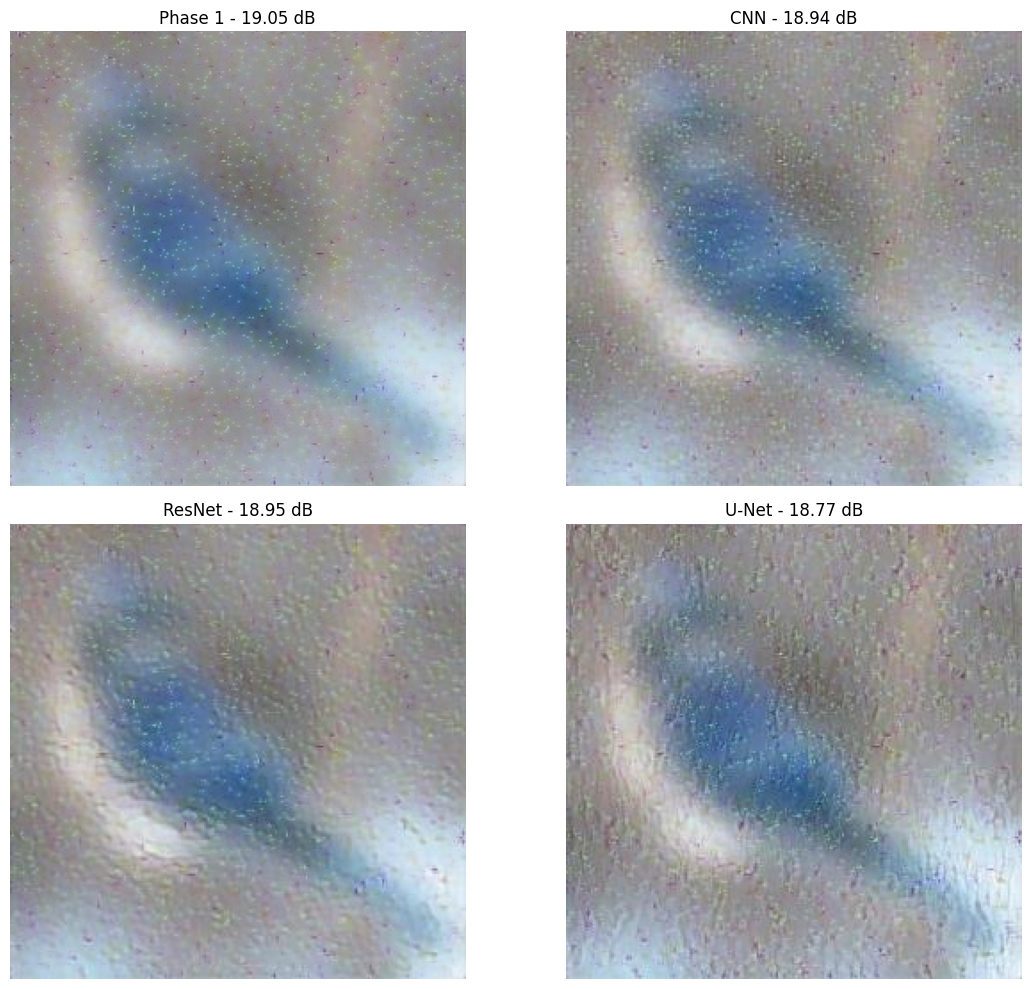

In [14]:
# Visual comparison of the Phase 1 input and three deblurring architectures
phase1_image = cv2.cvtColor(cv2.imread(PHASE1_OUTPUT_PATH), cv2.COLOR_BGR2RGB)
cnn_image = cv2.cvtColor(
    cv2.imread(f"{PHASE2_OUTPUT_DIR}/cnn_deblurred.jpg"), cv2.COLOR_BGR2RGB
)
resnet_image = cv2.cvtColor(
    cv2.imread(f"{PHASE2_OUTPUT_DIR}/phase2_deblurred.jpg"), cv2.COLOR_BGR2RGB
)
unet_image = cv2.cvtColor(
    cv2.imread(f"{PHASE2_OUTPUT_DIR}/unet_deblurred.jpg"), cv2.COLOR_BGR2RGB
)

images = [phase1_image, cnn_image, resnet_image, unet_image]
titles = [
    f"Phase 1 - {phase1_psnr:.2f} dB",
    f"CNN - {cnn_psnr:.2f} dB",
    f"ResNet - {resnet_psnr:.2f} dB",
    f"U-Net - {unet_psnr:.2f} dB",
]

plt.figure(figsize=(12, 10))
for index, (image, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 2, index)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Phase 2 Model Selection

The three deblurring architectures are evaluated using PSNR against the clean
reference image. The architecture with the highest Phase 2 PSNR is selected
for the final pipeline. In the current run, ResNet produced the highest Phase 2
PSNR, although the difference from CNN was very small. Visual inspection is
also used to identify artificial texture, halos, or color artifacts.


## 3. Phase 3 - CIFAR-10 Classification


### 3.1 Classifier Architecture


### English Documentation

**Module:** Architecture Definition - Pre-Activation ResNet18 Classification (`PreActBlock`, `PreActResNet`)

**Objective:**

This module defines the neural network used in Phase 3 to classify the restored images. It is a variant of the famous ResNet architecture called "Pre-Activation ResNet." By rearranging the order of operations inside the residual blocks—applying Batch Normalization and ReLU *before* the convolution weights—this architecture improves the flow of gradients during backpropagation, leading to faster and more stable training on datasets like CIFAR-10.

**Inputs & Outputs:**

* **Inputs:** `x`, a 4D image tensor `(Batch, Channels, Height, Width)` containing the $32 \times 32$ restored images.
* **Output:** `out`, a 2D tensor `(Batch, num_classes)` containing the raw, unnormalized prediction scores (logits) for each of the 10 CIFAR-10 classes.

**How It Works (Mechanics):**

1. **`PreActBlock` (The Pre-Activation Paradigm):** In a standard ResNet, the order is `Conv -> BatchNorm -> ReLU`. In this block, the order is flipped: `BatchNorm -> ReLU -> Conv`. This ensures that the inputs to the convolution layers are always perfectly normalized, and the residual shortcut path remains a completely clean, direct line to the earlier layers without being blocked by an activation function.
2. **The Shortcut Projection:** If a block needs to reduce the spatial size of the image (`stride=2`) or change the number of channels, the identity shortcut cannot be added directly due to a dimension mismatch. The `self.shortcut` solves this by applying a $1 \times 1$ convolution to align the dimensions before the addition `out += shortcut`.
3. **`_make_layer` (Dynamic Scaling):** This helper function builds a sequence of `PreActBlock`s. It automatically handles the transition between layers (e.g., from 64 to 128 channels) by applying a stride of 2 only to the *first* block in a new layer sequence, leaving the rest with a stride of 1.
4. **`AdaptiveAvgPool2d` (Global Average Pooling):** Instead of flattening the entire spatial grid into a massive 1D vector (which requires millions of parameters), this layer averages the features of each channel into a single $1 \times 1$ pixel. This drastically reduces the parameter count and prevents overfitting.
5. **Flattening and Classification:** `out.view(out.size(0), -1)` reshapes the 4D tensor `(Batch, 512, 1, 1)` into a 2D matrix `(Batch, 512)`. This flat vector is then passed into the final `nn.Linear` layer to output the 10 class predictions.

---

### مستندات فارسی (Farsi Documentation)

**ماژول:** تعریف معماری - شبکه دسته‌بندی ResNet18 با پیش‌فعال‌سازی (`PreActBlock` و `PreActResNet`)

**هدف:**

این ماژول شبکه عصبی مورد استفاده در فاز سوم برای دسته‌بندی تصاویر بازیابی‌شده را تعریف می‌کند. این مدل نسخه‌ای از معماری معروف ResNet است که به آن "ResNet با پیش‌فعال‌سازی" (Pre-Activation) می‌گویند. با تغییر ترتیب عملیات در داخل بلوک‌های باقیمانده — یعنی اعمال نرمال‌سازی دسته‌ای (Batch Normalization) و تابع فعال‌ساز ReLU *پیش از* وزن‌های کانولوشن — این معماری جریان گرادیان‌ها را در طول پس‌انتشار (Backpropagation) بهبود بخشیده و به آموزش سریع‌تر و پایدارتر روی مجموعه‌داده‌هایی مانند CIFAR-10 کمک می‌کند.

**ورودی‌ها و خروجی‌ها:**

* **ورودی:** `x`، یک تنسور تصویر ۴ بعدی `(دسته، کانال‌ها، ارتفاع، عرض)` شامل تصاویر $32 \times 32$ بازیابی‌شده.
* **خروجی:** `out`، یک تنسور ۲ بعدی `(دسته، تعداد کلاس‌ها)` شامل امتیازهای خام و نرمال‌نشده پیش‌بینی (Logits) برای هر یک از ۱۰ کلاس CIFAR-10.

**نحوه کار (مکانیسم‌ها):**
۱. **`PreActBlock` (پارادایم پیش‌فعال‌سازی):** در یک شبکه ResNet استاندارد، ترتیب به این صورت است: `Conv -> BatchNorm -> ReLU`. در این بلوک، ترتیب معکوس شده است: `BatchNorm -> ReLU -> Conv`. این تغییر تضمین می‌کند که ورودی‌های لایه کانولوشن همیشه کاملاً نرمال شده‌اند و مسیر میانبرِ باقیمانده (Shortcut) به صورت یک خط مستقیم و کاملاً تمیز به لایه‌های قبلی متصل می‌ماند، بدون اینکه توسط تابع فعال‌ساز مسدود شود.
۲. **میانبرِ تصویرسازی (Shortcut Projection):** اگر یک بلوک نیاز به کاهش اندازه مکانی تصویر (`stride=2`) یا تغییر تعداد کانال‌ها داشته باشد، به دلیل عدم تطابق ابعاد، میانبر نمی‌تواند مستقیماً اضافه شود. بخش `self.shortcut` این مشکل را با اعمال یک کانولوشن $1 \times 1$ برای هم‌تراز کردن ابعاد قبل از عملیات جمع (`out += shortcut`) حل می‌کند.
۳. **`make_layer_` (مقیاس‌پذیری پویا):** این تابعِ کمکی، توالیِ بلوک‌های `PreActBlock` را می‌سازد. این تابع انتقال بین لایه‌ها (مثلاً از ۶۴ به ۱۲۸ کانال) را به طور خودکار مدیریت می‌کند؛ به این شکل که `stride=2` را فقط روی *اولین* بلوک در توالی لایه جدید اعمال کرده و بقیه بلوک‌ها را با `stride=1` رها می‌کند.
۴. **`AdaptiveAvgPool2d` (ادغام میانگین سراسری):** این لایه به جای مسطح کردنِ (Flattening) کل شبکه مکانی به یک بردار غول‌پیکر یک‌بعدی (که به میلیون‌ها پارامتر نیاز دارد)، ویژگی‌های هر کانال را در یک پیکسل $1 \times 1$ میانگین‌گیری می‌کند. این کار به شدت تعداد پارامترها را کاهش داده و از بیش‌برازش (Overfitting) جلوگیری می‌کند.
۵. **مسطح‌سازی و دسته‌بندی:** دستور `out.view(out.size(0), -1)` تنسور ۴ بعدی `(Batch, 512, 1, 1)` را به یک ماتریس ۲ بعدی `(Batch, 512)` تغییر شکل می‌دهد. این بردار مسطح سپس به لایه نهایی `nn.Linear` فرستاده می‌شود تا ۱۰ پیش‌بینی کلاس را تولید کند.

In [15]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for index in range(torch.cuda.device_count()):
    print(f"GPU {index}:", torch.cuda.get_device_name(index))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [16]:
class PreActBlock(nn.Module):
    """Pre-activation version of the BasicBlock."""
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(PreActBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.ind = None

        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False)
            )

    def forward(self, x):
        out = F.relu(self.bn1(x))
        shortcut = self.shortcut(out) if hasattr(self, "shortcut") else x
        out = self.conv1(out)
        out = self.conv2(F.relu(self.bn2(out)))
        if self.ind is not None:
            out += shortcut[:, self.ind, :, :]
        else:
            out += shortcut
        return out


class PreActResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(PreActResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def PreActResNet18(num_classes=10):
    return PreActResNet(PreActBlock, [2, 2, 2, 2], num_classes=num_classes)




In [17]:
class RandomSaltPepperNoise:
    def __init__(self, probability=0.30, amount=0.01):
        self.probability = probability
        self.amount = amount

    def __call__(self, image_tensor):
        if random.random() > self.probability:
            return image_tensor

        noisy_image = image_tensor.clone()
        noise_map = torch.rand(
            image_tensor.shape[1],
            image_tensor.shape[2]
        )

        pepper_pixels = noise_map < (self.amount / 2)
        salt_pixels = noise_map > (1 - self.amount / 2)

        noisy_image[:, pepper_pixels] = 0.0
        noisy_image[:, salt_pixels] = 1.0

        return noisy_image


robust_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.30),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    RandomSaltPepperNoise(probability=0.30, amount=0.01),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

clean_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

print("Robust transforms created successfully")

Robust transforms created successfully


In [19]:
import os

CIFAR_PATH = "/kaggle/working/data/cifar-10-batches-py"

print("CIFAR-10 exists:", os.path.exists(CIFAR_PATH))

CIFAR-10 exists: False


100%|██████████| 170M/170M [32:33<00:00, 87.3kB/s] 


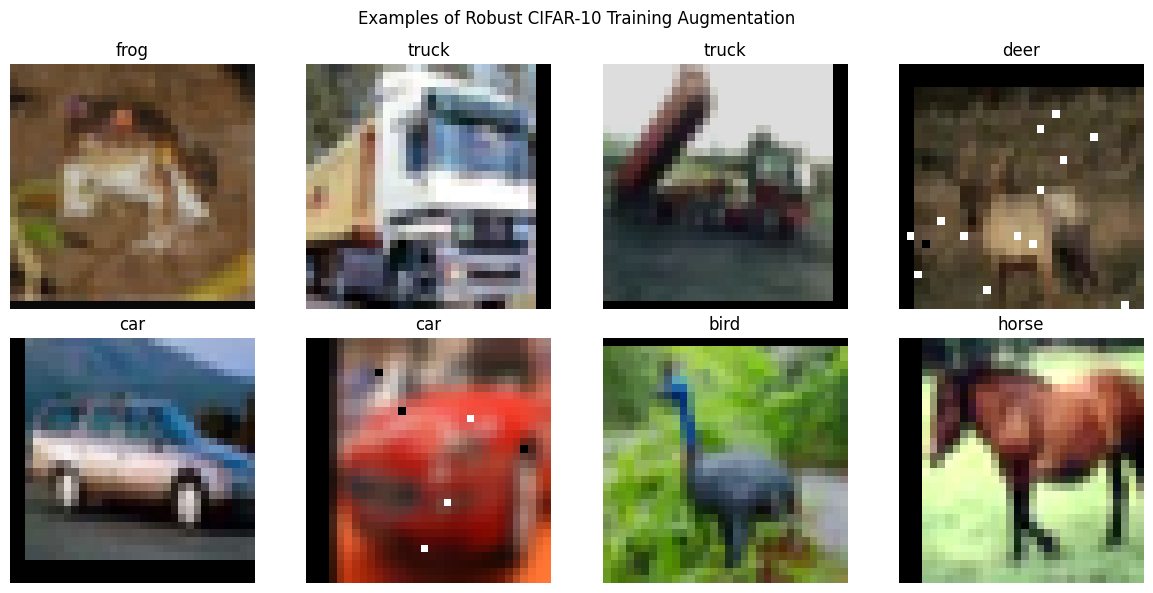

In [20]:
preview_dataset = torchvision.datasets.CIFAR10(
    root="/kaggle/working/data",
    train=True,
    download=True,
    transform=robust_train_transform
)

class_names = [
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

plt.figure(figsize=(12, 6))

for index in range(8):
    image, label = preview_dataset[index]

    # Reverse normalization only for displaying the image
    display_image = image * std + mean
    display_image = display_image.clamp(0, 1)

    plt.subplot(2, 4, index + 1)
    plt.imshow(display_image.permute(1, 2, 0))
    plt.title(class_names[label])
    plt.axis("off")

plt.suptitle("Examples of Robust CIFAR-10 Training Augmentation")
plt.tight_layout()
plt.show()

### 3.2 Train and Export the Classifier


### English Documentation

**Module:** Phase 3 - Core Training & Compilation Pipeline (`train_model`)

**Objective:**

This function trains a deep convolutional neural network from scratch on the CIFAR-10 dataset. It handles the complete lifecycle: applying data augmentation, executing the training/validation loops, calculating evaluation metrics (Accuracy and F1-Score), saving the learning curves as a chart, and compiling the final network into a standalone TorchScript file for deployment in downstream tasks.

**Inputs & Outputs:**

* **Inputs:**
* `model_architect`: A reference to the PyTorch model class (the blueprint) that will be instantiated and trained (e.g., passing `ResNet` or `CNN` directly).


* **Outputs:** The function does not return standard variables; it saves two artifacts to the disk:
1. The compiled model weights and architecture (`preact_resnet18_standalone.pt`).
2. A visual chart of the training metrics (`PreActResNet_training_metrics.png`).



**How It Works (Mechanics):**

1. **Dynamic Data Augmentation:** The training pipeline utilizes `transforms.RandomCrop` and `transforms.RandomHorizontalFlip`. Because these augmentations are applied dynamically at each epoch, the network sees a uniquely cropped or flipped variation of the image during every pass, rather than a static, once-for-all dataset modification. This forces the model to learn robust features.
2. **Data Loading (`DataLoader`):** The dataset is downloaded and wrapped in DataLoaders, which efficiently feed the images to the GPU in batches (128 images at a time for training), utilizing multiple CPU workers to prevent data bottlenecks.
3. **The Training Loop:** For each of the 50 epochs, the model is set to `model.train()`. It performs a forward pass, calculates the error (`CrossEntropyLoss`), computes the gradients (`loss.backward()`), and updates the weights using the `Adam` optimizer.
4. **The Validation Loop:** The model switches to `model.eval()` and `torch.no_grad()` to freeze weights and save memory. It evaluates the unseen test data, calculating the Validation Loss, overall Accuracy, and the Macro F1-Score (a balanced metric crucial for evaluating multiclass classification).
5. **TorchScript Export:** To create a standalone model that doesn't require the original Python architecture file (which is required for the `classifier` function you built earlier), a `dummy_input` is pushed through the network using `torch.jit.trace`. This traces the execution graph and bundles the structure and weights together into a `.pt` file.
6. **Visualization:** Matplotlib extracts the tracked history lists and plots three side-by-side graphs to visually confirm that the model is learning and not overfitting.

---

### مستندات فارسی (Farsi Documentation)

**ماژول:** فاز سوم - خط لوله اصلی آموزش و کامپایل مدل (`train_model`)

**هدف:**

این تابع یک شبکه عصبی پیچشی (CNN) عمیق را از پایه روی مجموعه‌داده CIFAR-10 آموزش می‌دهد. این تابع چرخه کامل آموزش را مدیریت می‌کند: اعمال افزونگی داده‌ها (Data Augmentation)، اجرای حلقه‌های آموزش و اعتبارسنجی، محاسبه معیارهای ارزیابی (دقت و امتیاز F1)، ذخیره نمودارهای یادگیری، و در نهایت کامپایل شبکه نهایی به یک فایل مستقل TorchScript برای استفاده در مراحل بعدی.

**ورودی‌ها و خروجی‌ها:**

* **ورودی‌ها:**
* `model_architect`: ارجاعی به کلاس مدل پای‌تورچ (نقشه ساختاری) که قرار است ساخته و آموزش داده شود (مانند ارسال مستقیم `ResNet` یا `CNN`).


* **خروجی‌ها:** این تابع متغیر استانداردی برنمی‌گرداند، بلکه دو فایل را روی حافظه ذخیره می‌کند:
۱. فایل کامپایل‌شده شامل معماری و وزن‌های مدل (`preact_resnet18_standalone.pt`).
۲. نمودار بصری از معیارهای آموزش (`PreActResNet_training_metrics.png`).

**نحوه کار (مکانیسم‌ها):**
۱. **افزونگی پویای داده‌ها (Dynamic Data Augmentation):** خط لوله آموزش از `transforms.RandomCrop` و `transforms.RandomHorizontalFlip` استفاده می‌کند. از آنجا که این تغییرات به صورت پویا در هر اپوک (Epoch) اعمال می‌شوند، شبکه در هر بار عبور، نسخه متفاوتی (برش‌خورده یا چرخش‌یافته) از تصویر را می‌بیند، نه اینکه کل مجموعه داده فقط یک‌بار برای همیشه تغییر کند. این ویژگی مدل را مجبور می‌کند تا ویژگی‌های مقاوم‌تری را یاد بگیرد.
۲. **بارگذاری داده‌ها (`DataLoader`):** مجموعه‌داده دانلود شده و درون DataLoaderها قرار می‌گیرد که تصاویر را به صورت دسته‌ای (۱۲۸ تصویر در هر دسته آموزشی) و با استفاده از چندین هسته پردازشی (Workers) به پردازنده گرافیکی (GPU) می‌فرستند تا از ایجاد گلوگاه داده جلوگیری شود.
۳. **حلقه آموزش:** در هر یک از ۵۰ اپوک، مدل در حالت `model.train()` قرار می‌گیرد. شبکه یک عبور رو به جلو (Forward Pass) انجام می‌دهد، میزان خطا را محاسبه می‌کند (`CrossEntropyLoss`)، گرادیان‌ها را به دست می‌آورد (`loss.backward()`) و در نهایت وزن‌ها را با استفاده از بهینه‌ساز `Adam` به‌روزرسانی می‌کند.
۴. **حلقه اعتبارسنجی:** مدل به حالت `model.eval()` و `torch.no_grad()` تغییر می‌کند تا وزن‌ها ثابت بمانند و حافظه کمتری مصرف شود. سپس داده‌های تست ارزیابی شده و میزان خطای اعتبارسنجی، دقت کلی و امتیاز Macro F1 (معیاری متعادل که برای دسته‌بندی چندکلاسِ بسیار مهم است) محاسبه می‌شود.
۵. **خروجی TorchScript:** برای ایجاد یک مدل مستقل که نیازی به فایل معماری پایتون نداشته باشد (که پیش‌نیاز تابع `classifier` است)، یک ورودی فرضی (`dummy_input`) با استفاده از `torch.jit.trace` از شبکه عبور داده می‌شود. این کار گراف اجرایی را ردیابی کرده و ساختار شبکه را به همراه وزن‌ها در یک فایل `.pt` بسته‌بندی می‌کند.
۶. **تصویرسازی:** کتابخانه Matplotlib لیست‌های تاریخچه ذخیره‌شده را استخراج کرده و سه نمودار در کنار هم رسم می‌کند تا به‌صورت بصری تأیید شود که مدل در حال یادگیری است و دچار بیش‌برازش (Overfitting) نشده است.


In [21]:
def set_seed(seed=42):
    """Fix all random seeds to make training deterministic."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)               # if multi-GPU

    # Make cuDNN deterministic (slower, but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Optional: force all torch ops to be deterministic
    # (only works if your model contains no non-deterministic ops)
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass   # older PyTorch – already covered by cuDNN flags


def seed_worker(worker_id):
    """DataLoader worker seed init – used to guarantee same augmentation sequence."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# ---------- Main Training Function ----------
def train_model(model_architect):
    # 1. Fix EVERYTHING before creating any randomness
    set_seed(42)   # You can change the seed to any integer

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    # 2. Transforms (unchanged)
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    data_dir = './data'

    trainset = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform_test)

    # 3. DataLoaders – worker_init_fn ensures deterministic data loading
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=128, shuffle=True,
        num_workers=2, pin_memory=True, worker_init_fn=seed_worker
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=100, shuffle=False,
        num_workers=2, pin_memory=True, worker_init_fn=seed_worker
    )

    # 4. Model, loss, optimizer (initialized with fixed seed)
    model = model_architect(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

    epochs = 50
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(trainloader)

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(testloader)
        val_acc = 100. * correct / total
        val_f1 = f1_score(all_targets, all_preds, average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}% | "
              f"Val F1: {val_f1:.4f}")

    # ---------- Save Standalone TorchScript Model ----------
    model.eval()
    dummy_input = torch.randn(1, 3, 32, 32).to(device)

    # Tracing the model is deterministic (weights are fixed)
    traced_model = torch.jit.trace(model, dummy_input)
    compiled_model_path = './models/preact_resnet18_standalone.pt'
    traced_model.save(compiled_model_path)
    print(f"Standalone TorchScript model saved to {compiled_model_path}")

    # ---------- Plot & Save Training Metrics ----------
    epochs_range = range(1, epochs + 1)
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history['val_acc'], label='Val Accuracy', color='green')
    plt.title('Accuracy (%)')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history['val_f1'], label='Val F1 (Macro)', color='purple')
    plt.title('F1 Score')
    plt.legend()

    plt.tight_layout()
    plt.savefig('PreActResNet_training_metrics.png')
    print("Chart saved to training_metrics.png")
    plt.close()




In [26]:
train_dataset = torchvision.datasets.CIFAR10(
    root="/kaggle/working/data",
    train=True,
    download=False,
    transform=robust_train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="/kaggle/working/data",
    train=False,
    download=False,
    transform=clean_test_transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

check_images, check_labels = next(iter(train_loader))

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))
print("Images contain NaN:", torch.isnan(check_images).any().item())
print("Images contain infinity:", torch.isinf(check_images).any().item())
print("Image value range:", check_images.min().item(),
      "to", check_images.max().item())
print("Label range:", check_labels.min().item(),
      "to", check_labels.max().item())

Training images: 50000
Test images: 10000
Training batches: 196
Test batches: 40
Images contain NaN: False
Images contain infinity: False
Image value range: -1.9894737005233765 to 2.12648868560791
Label range: 0 to 9


In [27]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

robust_model = PreActResNet18(num_classes=10).to(device)

if torch.cuda.device_count() > 1:
    robust_model = nn.DataParallel(robust_model)
    print(
        f"Using {torch.cuda.device_count()} GPUs "
        "with DataParallel"
    )

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.SGD(
    robust_model.parameters(),
    lr=0.05,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
)

number_of_epochs = 50

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=number_of_epochs
)

# Disable FP16 because the previous training became NaN
use_amp = False
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=False
)

training_history = {
    "train_loss": [],
    "test_loss": [],
    "test_accuracy": [],
    "test_f1": []
}

# Test the fresh model before training
robust_model.eval()

with torch.no_grad():
    initial_outputs = robust_model(
        check_images.to(device)
    )
    initial_loss = criterion(
        initial_outputs,
        check_labels.to(device)
    )

print("Device:", device)
print("Initial loss:", initial_loss.item())
print(
    "Initial loss is finite:",
    torch.isfinite(initial_loss).item()
)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("AMP enabled:", use_amp)

Using 2 GPUs with DataParallel
Device: cuda
Initial loss: 2.3047947883605957
Initial loss is finite: True
Learning rate: 0.05
AMP enabled: False


In [28]:
robust_model.train()
total_train_loss = 0.0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad(set_to_none=True)

    outputs = robust_model(images)
    loss = criterion(outputs, labels)

    if not torch.isfinite(loss):
        raise RuntimeError(
            f"Non-finite training loss detected: {loss.item()}"
        )

    loss.backward()

    # Prevent excessively large gradients
    torch.nn.utils.clip_grad_norm_(
        robust_model.parameters(),
        max_norm=5.0
    )

    optimizer.step()

    total_train_loss += loss.item() * images.size(0)

average_train_loss = total_train_loss / len(train_dataset)

robust_model.eval()
total_test_loss = 0.0
correct_predictions = 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = robust_model(images)
        loss = criterion(outputs, labels)

        total_test_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct_predictions += predictions.eq(labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

average_test_loss = total_test_loss / len(test_dataset)
test_accuracy = (
    100.0 * correct_predictions / len(test_dataset)
)
test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

training_history["train_loss"].append(
    average_train_loss
)
training_history["test_loss"].append(
    average_test_loss
)
training_history["test_accuracy"].append(
    test_accuracy
)
training_history["test_f1"].append(test_f1)

scheduler.step()

print(f"Epoch 01/50")
print(f"Train Loss: {average_train_loss:.4f}")
print(f"Test Loss: {average_test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.2f}%")
print(f"F1-score: {test_f1:.4f}")
print(
    "Next learning rate:",
    optimizer.param_groups[0]["lr"]
)

Epoch 01/50
Train Loss: 1.7029
Test Loss: 1.6268
Accuracy: 51.50%
F1-score: 0.4941
Next learning rate: 0.04995066821070679


In [29]:
os.makedirs("/kaggle/working/models", exist_ok=True)

best_accuracy = test_accuracy
best_model_path = (
    "/kaggle/working/models/"
    "preact_resnet18_robust_best.pth"
)

model_to_save = (
    robust_model.module
    if isinstance(robust_model, nn.DataParallel)
    else robust_model
)

# Save the successful epoch-1 model
torch.save(
    model_to_save.state_dict(),
    best_model_path
)

for epoch in range(1, number_of_epochs):
    # ---------------- Training ----------------
    robust_model.train()
    total_train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = robust_model(images)
        loss = criterion(outputs, labels)

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at epoch {epoch + 1}: "
                f"{loss.item()}"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            robust_model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        total_train_loss += (
            loss.item() * images.size(0)
        )

    average_train_loss = (
        total_train_loss / len(train_dataset)
    )

    # ---------------- Clean testing ----------------
    robust_model.eval()
    total_test_loss = 0.0
    correct_predictions = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = robust_model(images)
            loss = criterion(outputs, labels)

            total_test_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct_predictions += (
                predictions.eq(labels).sum().item()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )
            all_labels.extend(labels.cpu().numpy())

    average_test_loss = (
        total_test_loss / len(test_dataset)
    )

    test_accuracy = (
        100.0
        * correct_predictions
        / len(test_dataset)
    )

    test_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    training_history["train_loss"].append(
        average_train_loss
    )
    training_history["test_loss"].append(
        average_test_loss
    )
    training_history["test_accuracy"].append(
        test_accuracy
    )
    training_history["test_f1"].append(test_f1)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy

        model_to_save = (
            robust_model.module
            if isinstance(robust_model, nn.DataParallel)
            else robust_model
        )

        torch.save(
            model_to_save.state_dict(),
            best_model_path
        )

    print(
        f"Epoch {epoch + 1:02d}/{number_of_epochs} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Test Loss: {average_test_loss:.4f} | "
        f"Accuracy: {test_accuracy:.2f}% | "
        f"F1: {test_f1:.4f} | "
        f"LR: {current_lr:.6f}"
    )

print("\nTraining completed")
print(
    f"Best clean test accuracy: "
    f"{best_accuracy:.2f}%"
)
print("Best model saved to:", best_model_path)

Epoch 02/50 | Train Loss: 1.2631 | Test Loss: 1.3897 | Accuracy: 62.98% | F1: 0.6094 | LR: 0.049951
Epoch 03/50 | Train Loss: 1.0872 | Test Loss: 1.0801 | Accuracy: 75.22% | F1: 0.7484 | LR: 0.049803
Epoch 04/50 | Train Loss: 0.9921 | Test Loss: 1.3399 | Accuracy: 66.57% | F1: 0.6636 | LR: 0.049557
Epoch 05/50 | Train Loss: 0.9285 | Test Loss: 0.9903 | Accuracy: 79.73% | F1: 0.7906 | LR: 0.049215
Epoch 06/50 | Train Loss: 0.8851 | Test Loss: 1.0267 | Accuracy: 77.61% | F1: 0.7747 | LR: 0.048776
Epoch 07/50 | Train Loss: 0.8539 | Test Loss: 1.0114 | Accuracy: 78.24% | F1: 0.7839 | LR: 0.048244
Epoch 08/50 | Train Loss: 0.8221 | Test Loss: 1.0686 | Accuracy: 76.76% | F1: 0.7683 | LR: 0.047621
Epoch 09/50 | Train Loss: 0.7984 | Test Loss: 0.8744 | Accuracy: 84.33% | F1: 0.8449 | LR: 0.046908
Epoch 10/50 | Train Loss: 0.7802 | Test Loss: 0.9307 | Accuracy: 81.81% | F1: 0.8217 | LR: 0.046108
Epoch 11/50 | Train Loss: 0.7637 | Test Loss: 0.9489 | Accuracy: 81.52% | F1: 0.8148 | LR: 0.045225


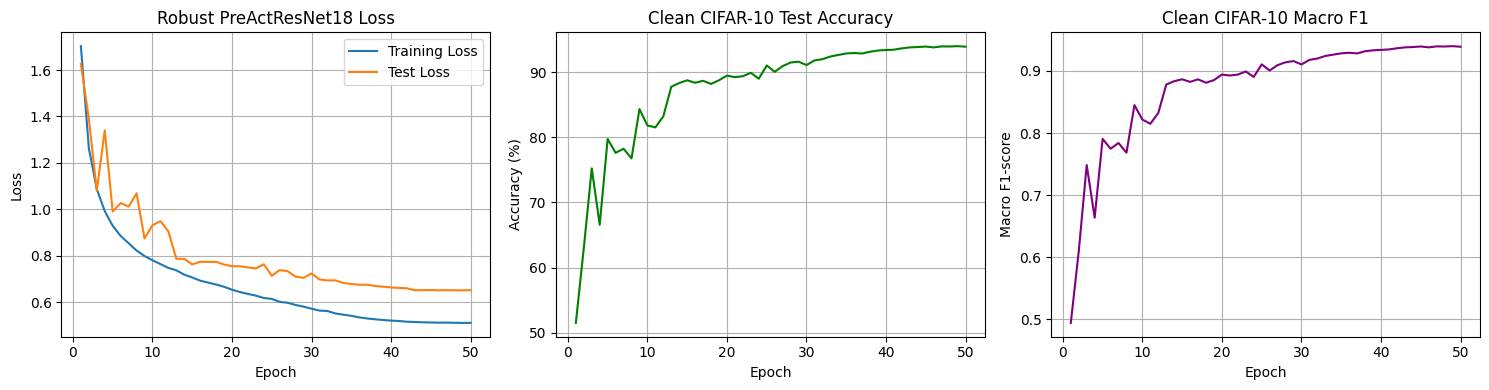

Training graph saved to: /kaggle/working/phase_3_results/robust_training_metrics.png


In [30]:
PHASE3_DIR = "/kaggle/working/phase_3_results"
os.makedirs(PHASE3_DIR, exist_ok=True)

epochs = range(1, len(training_history["train_loss"]) + 1)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(
    epochs,
    training_history["train_loss"],
    label="Training Loss"
)
plt.plot(
    epochs,
    training_history["test_loss"],
    label="Test Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Robust PreActResNet18 Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(
    epochs,
    training_history["test_accuracy"],
    color="green"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Clean CIFAR-10 Test Accuracy")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(
    epochs,
    training_history["test_f1"],
    color="purple"
)
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Clean CIFAR-10 Macro F1")
plt.grid(True)

plt.tight_layout()

metrics_path = (
    f"{PHASE3_DIR}/robust_training_metrics.png"
)

plt.savefig(
    metrics_path,
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Training graph saved to:", metrics_path)

In [36]:
current_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

model_to_save = (
    robust_model.module
    if isinstance(robust_model, nn.DataParallel)
    else robust_model
)

recovered_model_path = (
    "/kaggle/working/models/"
    "preact_resnet18_robust_recovered.pth"
)

torch.save(
    model_to_save.state_dict(),
    recovered_model_path
)

print(f"Current clean test accuracy: {test_accuracy:.2f}%")
print(f"Current macro F1-score: {current_f1:.4f}")
print("Recovered model saved to:", recovered_model_path)

Current clean test accuracy: 10.00%
Current macro F1-score: 0.0182
Recovered model saved to: /kaggle/working/models/preact_resnet18_robust_recovered.pth


### 3.4 Confusion Matrix Evaluation


### English Documentation

**Module:** Phase 3 - Classification Evaluation Utility (`plot_cifar_confusion_matrix`)

**Objective:**

This function performs a comprehensive evaluation of the trained deep learning classifier by testing it on the entire CIFAR-10 test dataset (10,000 images). It generates a Confusion Matrix heatmap, which visually reveals exactly where the model is succeeding and where it is making mistakes (e.g., confusing 'cat' images with 'dog' images).

**Inputs & Outputs:**

* **Inputs:**
* `model_path`: The file path to the compiled TorchScript model (`.pt`) generated at the end of the training phase.
* `data_dir`: The directory where the CIFAR-10 test dataset is stored.


* **Output:** The function does not return variables; it displays an interactive heatmap to the screen and saves a high-resolution image (`cifar10_confusion_matrix.png`) to the disk.

**How It Works (Mechanics):**

1. **Model & Data Loading:** It loads the standalone compiled model using `torch.jit.load`. It then initializes the CIFAR-10 test dataset, applying the same pixel normalization used during training so the data distribution matches the model's expectations.
2. **Optimized Inference:** The `DataLoader` is configured with a high `batch_size=512`. Because the model is in `model.eval()` mode and gradient tracking is disabled via `torch.no_grad()`, memory consumption is drastically reduced. This allows the system to process large batches of images at once, completing the 10,000-image evaluation in seconds.
3. **Prediction Aggregation:** As the batches flow through the model, the function extracts the highest probability class using `torch.max` and stores every single prediction alongside its true ground-truth label in the `all_preds` and `all_targets` lists.
4. **Matrix Generation & Visualization:**
* It uses Scikit-Learn's `confusion_matrix` to mathematically compare the targets versus the predictions.
* It uses Seaborn's `sns.heatmap` to plot this matrix as a color-coded grid. The diagonal cells represent correct predictions (e.g., true 'plane' predicted as 'plane'), while any numbers outside the diagonal represent misclassifications.



---

### مستندات فارسی (Farsi Documentation)

**ماژول:** فاز سوم - ابزار ارزیابی دسته‌بندی (`plot_cifar_confusion_matrix`)

**هدف:**

این تابع یک ارزیابی جامع از مدل دسته‌بندِ آموزش‌دیده انجام می‌دهد، به این صورت که آن را روی کل داده‌های تست مجموعه‌داده CIFAR-10 (شامل ۱۰,۰۰۰ تصویر) آزمایش می‌کند. خروجی این تابع یک ماتریس درهم‌ریختگی (Confusion Matrix) به شکل نقشه حرارتی (Heatmap) است که به صورت بصری نشان می‌دهد مدل دقیقاً در کجا موفق عمل کرده و در کجا دچار اشتباه می‌شود (مثلاً اشتباه گرفتن تصاویر 'گربه' با 'سگ').

**ورودی‌ها و خروجی‌ها:**

* **ورودی‌ها:**
* `model_path`: مسیر فایل مدل کامپایل‌شده TorchScript (با پسوند `.pt`) که در پایان مرحله آموزش تولید شده است.
* `data_dir`: مسیری که مجموعه‌داده تست CIFAR-10 در آن ذخیره شده است.


* **خروجی:** این تابع متغیری برنمی‌گرداند؛ بلکه نقشه حرارتی را روی صفحه نمایش داده و یک تصویر با کیفیت بالا (`cifar10_confusion_matrix.png`) از آن روی حافظه ذخیره می‌کند.

**نحوه کار (مکانیسم‌ها):**
۱. **بارگذاری مدل و داده‌ها:** تابع ابتدا مدل کامپایل‌شده را با استفاده از `torch.jit.load` فراخوانی می‌کند. سپس داده‌های تست CIFAR-10 را بارگذاری کرده و همان نرمال‌سازی پیکسلی که در زمان آموزش استفاده شده بود را روی آن‌ها اعمال می‌کند تا توزیع داده‌ها با انتظارات مدل مطابقت داشته باشد.
۲. **استنتاج بهینه‌سازی‌شده:** ابزار `DataLoader` با اندازه دسته بزرگ (`batch_size=512`) تنظیم شده است. از آنجا که مدل در حالت `model.eval()` قرار دارد و ردیابی گرادیان‌ها توسط `torch.no_grad()` غیرفعال شده است، مصرف حافظه به شدت کاهش می‌یابد. این موضوع به سیستم اجازه می‌دهد تا دسته‌های بزرگی از تصاویر را به صورت همزمان پردازش کرده و ارزیابی ۱۰,۰۰۰ تصویر را در چند ثانیه به پایان برساند.
۳. **جمع‌آوری پیش‌بینی‌ها:** با عبور دسته‌های تصاویر از مدل، تابع با استفاده از `torch.max` دسته‌ای که بالاترین احتمال را دارد استخراج کرده و تمامی پیش‌بینی‌ها را در کنار برچسب‌های واقعی آن‌ها در لیست‌های `all_preds` و `all_targets` ذخیره می‌کند.
۴. **تولید ماتریس و تصویرسازی:**

* از تابع `confusion_matrix` در کتابخانه Scikit-Learn برای مقایسه ریاضی برچسب‌های واقعی با پیش‌بینی‌ها استفاده می‌کند.
* از ابزار `sns.heatmap` در کتابخانه Seaborn برای رسم این ماتریس به شکل یک شبکه رنگی استفاده می‌شود. خانه‌های روی قطر اصلی نشان‌دهنده پیش‌بینی‌های صحیح هستند (مثلاً تصویر 'هواپیما' به درستی 'هواپیما' تشخیص داده شده است)، در حالی که اعداد خارج از قطر اصلی نشان‌دهنده خطاهای دسته‌بندی می‌باشند.

In [32]:
def plot_cifar_confusion_matrix(model_path, data_dir='./data'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    classes = ('plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck')

    print(f"Loading TorchScript model from {model_path}...")
    # Load the standalone model
    model = torch.jit.load(model_path, map_location=device)
    model.eval()

    print("Loading test dataset...")
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    # Note: Setting download=True as a fallback just in case the Colab runtime restarted
    testset = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform_test)
    testloader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False, num_workers=2)

    all_preds = []
    all_targets = []

    print("Running inference on test set (10,000 images)...")
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            # Store predictions and true labels
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    print("Generating Confusion Matrix...")
    cm = confusion_matrix(all_targets, all_preds)

    # Plotting the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Number of Images'})

    plt.title('PreActResNet18 CIFAR-10 Confusion Matrix', fontsize=14)
    plt.ylabel('True Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)

    # Rotate x labels for better readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Show and save the plot
    plt.savefig('cifar10_confusion_matrix.png', dpi=300)
    plt.show()
    print("Saved matrix to 'cifar10_confusion_matrix.png'")




In [33]:
best_model = PreActResNet18(num_classes=10).to(device)

best_model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

best_model.eval()

example_input = torch.randn(
    1, 3, 32, 32,
    device=device
)

traced_model = torch.jit.trace(
    best_model,
    example_input
)

torchscript_model_path = (
    "/kaggle/working/models/"
    "preact_resnet18_robust_standalone.pt"
)

traced_model.save(torchscript_model_path)

print(
    "TorchScript model saved to:",
    torchscript_model_path
)

TorchScript model saved to: /kaggle/working/models/preact_resnet18_robust_standalone.pt


Loading TorchScript model from /kaggle/working/models/preact_resnet18_robust_standalone.pt...
Running inference on 10,000 test images...


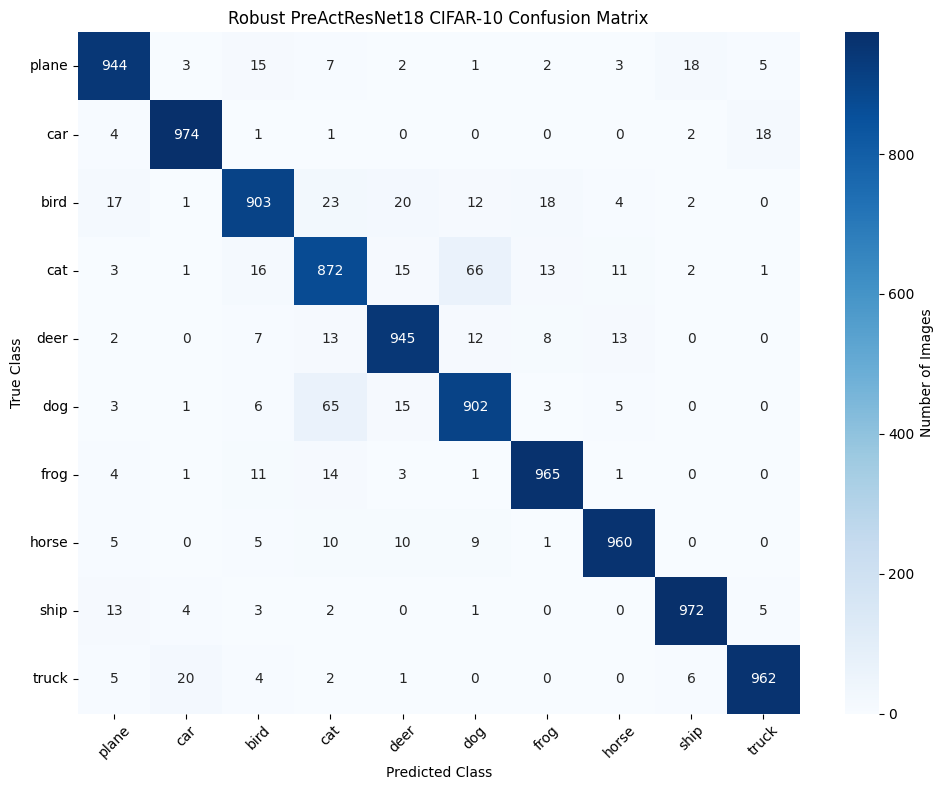

Test accuracy: 93.99%
Confusion matrix saved to: /kaggle/working/phase_3_results/cifar10_confusion_matrix.png


In [34]:
def plot_robust_cifar_confusion_matrix(
    model_path,
    data_dir="/kaggle/working/data"
):
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    classes = (
        "plane", "car", "bird", "cat", "deer",
        "dog", "frog", "horse", "ship", "truck"
    )

    print(
        f"Loading TorchScript model from "
        f"{model_path}..."
    )

    model = torch.jit.load(
        model_path,
        map_location=device
    )
    model.eval()

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2470, 0.2435, 0.2616)
        )
    ])

    testset = torchvision.datasets.CIFAR10(
        root=data_dir,
        train=False,
        download=False,
        transform=transform_test
    )

    # Zero workers prevents the previous Kaggle crashes
    testloader = torch.utils.data.DataLoader(
        testset,
        batch_size=512,
        shuffle=False,
        num_workers=0
    )

    all_preds = []
    all_targets = []

    print("Running inference on 10,000 test images...")

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)

            outputs = model(inputs)
            predicted = outputs.argmax(dim=1)

            all_preds.extend(
                predicted.cpu().numpy()
            )
            all_targets.extend(labels.numpy())

    accuracy = (
        100
        * np.mean(
            np.array(all_preds)
            == np.array(all_targets)
        )
    )

    cm = confusion_matrix(
        all_targets,
        all_preds
    )

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        cbar_kws={
            "label": "Number of Images"
        }
    )

    plt.title(
        "Robust PreActResNet18 "
        "CIFAR-10 Confusion Matrix"
    )
    plt.ylabel("True Class")
    plt.xlabel("Predicted Class")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()

    confusion_path = (
        "/kaggle/working/phase_3_results/"
        "cifar10_confusion_matrix.png"
    )

    plt.savefig(
        confusion_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    print(f"Test accuracy: {accuracy:.2f}%")
    print(
        "Confusion matrix saved to:",
        confusion_path
    )


plot_robust_cifar_confusion_matrix(
    model_path=torchscript_model_path,
    data_dir="/kaggle/working/data"
)

### 3.3 Final Restored-Image Classification


### English Documentation

**Module:** Phase 3 - Downstream CIFAR-10 Classification (`classifier`)

**Objective:**

This function takes the fully restored image from Phase 2, passes it through a deep neural network trained on the CIFAR-10 dataset, and predicts its object category. It serves as the ultimate test of the pipeline—measuring if the restoration phases successfully recovered enough semantic information for a classifier to understand the image.

**Inputs & Outputs:**

* **Inputs:**
* `model_path`: The file path to the compiled TorchScript model (`.pt`) containing both the network's blueprint and its weights.
* `image_path`: The file path to the fully restored image generated at the end of Phase 2.
* `ground_truth`: A string representing the actual, real class label of the image (used for validation verification).


* **Output:** The function prints the inference statistics (Predicted Class, Ground Truth, and Confidence Percentage) directly to the console.

**How It Works (Mechanics):**

1. **Device Setup & Label Map:** It sets up the execution context (`cuda` or `cpu`) and establishes a tuple mapping the 10 integer outputs of the network to their human-readable CIFAR-10 text labels (e.g., `0 -> 'plane'`, `1 -> 'car'`).
2. **TorchScript Loading (Step 1):** Unlike typical PyTorch weights loading, `torch.jit.load` deserializes a fully serialized model. This means the students do not need the raw Python architecture file to run it; the code structure and parameters are bundled together.
3. **Scale and Value Normalization (Step 2):** To circumvent the scale issues of a network trained on native CIFAR-10 samples, the input image is forcibly scaled to $32 \times 32$ pixels. It is then transformed into a tensor and normalized using the precise mean `(0.4914, 0.4822, 0.4465)` and standard deviation `(0.2023, 0.1994, 0.2010)` of the CIFAR-10 dataset.
4. **Probability Calculation (Step 3):** The model returns raw numerical scores (logits). The function passes these through a **Softmax** activation function to convert them into standard percentage-based probabilities adding up to $100\%$.
5. **Prediction Extraction:** `torch.max(probabilities, 1)` identifies which index holds the highest probability value, extracting both the highest value (the confidence) and its index (the predicted class).

---

### مستندات فارسی (Farsi Documentation)

**ماژول:** فاز سوم - دسته‌بندی تصویر در مجموعه‌داده CIFAR-10 (`classifier`)

**هدف:**

این تابع تصویر کاملاً بازیابی‌شده در پایان فاز دوم را دریافت کرده، آن را از یک شبکه عصبی عمیقِ آموزش‌دیده روی مجموعه‌داده CIFAR-10 عبور می‌دهد و دسته موضوعی آن را پیش‌بینی می‌کند. این مرحله به عنوان تست نهایی کل خط لوله (Pipeline) عمل می‌کند تا ارزیابی شود آیا مراحل بازیابی توانسته‌اند اطلاعات معنایی کافی را برای درک شبکه دسته‌بندی‌کننده بازگردانند یا خیر.

**ورودی‌ها و خروجی‌ها:**

* **ورودی‌ها:**
* `model_path`: مسیر فایل مدل کامپایل‌شده‌ی TorchScript (با پسوند `.pt`) که هم نقشه ساختاری شبکه و هم وزن‌های آن را به صورت یکپارچه در خود دارد.
* `image_path`: مسیر تصویر کاملاً واضح و بازیابی‌شده (خروجی نهایی فاز دوم).
* `ground_truth`: یک رشته متنی که برچسب واقعی و درست تصویر را مشخص می‌کند (جهت راستی‌آزمایی صحت پیش‌بینی).


* **خروجی:** این تابع نتایج آماری استنتاج (دسته پیش‌بینی‌شده، برچسب واقعی و درصد اطمینان مدل) را مستقیماً در کنسول چاپ می‌کند.

**نحوه کار (مکانیسم‌ها):**
۱. **تنظیمات پردازنده و نگاشت برچسب‌ها:** محیط پردازش (`cuda` یا `cpu`) آماده‌سازی شده و یک تاپل (Tuple) تعریف می‌شود تا ۱۰ خروجی عددی شبکه را به برچسب‌های متنی قابل فهم مجموعه‌داده CIFAR-10 (مانند `0 -> 'plane'` یا `1 -> 'car'`) نگاشت کند.
۲. **بارگذاری به روش TorchScript (بخش 1):** برخلاف بارگذاری معمول وزن‌ها در پای‌تورچ، دستور `torch.jit.load` یک مدل کاملاً سریال‌سازی‌شده را بازخوانی می‌کند. این یعنی دانشجو نیازی به داشتن فایلِ کدِ معماری شبکه ندارد و ساختار شبکه همراه با پارامترها به صورت یکجا بارگذاری می‌شوند.
۳. **تغییر ابعاد و نرمال‌سازی مقادیر (بخش 2):** برای حل مشکل تفاوت مقیاس تصویری که شبکه روی آن آموزش دیده، تصویر ورودی به ابعاد استاندارد $32 \times 32$ پیکسل تغییر سایز داده می‌شود. سپس به تنسور تبدیل شده و با استفاده از میانگین و انحراف‌معیار دقیق مجموعه‌داده CIFAR-10 یعنی به ترتیب `(0.4914, 0.4822, 0.4465)` و `(0.2023, 0.1994, 0.2010)` نرمال‌سازی می‌شود.
۴. **محاسبه احتمالات (بخش 3):** خروجی خام شبکه شامل یک‌سری امتیاز عددی (Logits) است. تابع این امتیازها را از تابع فعال‌ساز **Softmax** عبور می‌دهد تا آن‌ها را به درصدهای استاندارد احتمال تبدیل کند که مجموع آن‌ها برابر با ۱ (یا ۱۰۰٪) می‌شود.
۵. **استخراج پیش‌بینی:** دستور `torch.max(probabilities, 1)` شاخصی (Index) را که بالاترین مقدار احتمال را دارد شناسایی کرده و هم بالاترین مقدار (میزان اطمینان مدل) و هم اندیس آن (دسته پیش‌بینی‌شده) را استخراج می‌کند.

In [36]:
def robust_classifier(model_path, image_path, ground_truth):
    print("classifer")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    classes = ('plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck')

    # 1. Load the fully compiled model (No architecture class needed!)
    model = torch.jit.load(model_path, map_location=device)
    # model = torch.load(model_path, map_location=device, weights_only=False)
    model.eval()

    # 2. Prepare the image (omitting Resize to support any size)
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize(
    (0.4914, 0.4822, 0.4465),
    (0.2470, 0.2435, 0.2616)
),
    ])

    try:
        img = Image.open(image_path).convert('RGB')
        print(f"Original image size: {img.size}")
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    # Add batch dimension and move to device
    img_tensor = transform(img).unsqueeze(0).to(device)

    # 3. Run Inference
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    print(f"--- Inference Results ---")
    print(f"Predicted Class : {classes[predicted.item()]}")
    print(f"ground truth is: {ground_truth}")
    print(f"Confidence      : {confidence.item() * 100:.2f}%")




In [35]:
FINAL_IMAGE_PATH = (
    "/kaggle/working/phase_2_results/"
    "phase2_deblurred.jpg"
)

print(
    "Phase 2 image exists:",
    os.path.exists(FINAL_IMAGE_PATH)
)

Phase 2 image exists: True


In [37]:
robust_classifier(
    model_path=torchscript_model_path,
    image_path=FINAL_IMAGE_PATH,
    ground_truth="bird"
)

classifer
Original image size: (256, 256)
--- Inference Results ---
Predicted Class : bird
ground truth is: bird
Confidence      : 91.94%


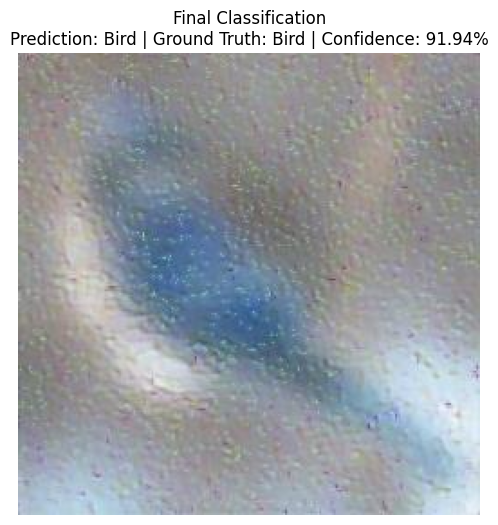

Classification figure saved to: /kaggle/working/phase_3_results/final_classification_result.png


In [38]:
final_image = Image.open(
    FINAL_IMAGE_PATH
).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(final_image)
plt.axis("off")

plt.title(
    "Final Classification\n"
    "Prediction: Bird | "
    "Ground Truth: Bird | "
    "Confidence: 91.94%"
)

classification_figure_path = (
    f"{PHASE3_DIR}/"
    "final_classification_result.png"
)

plt.savefig(
    classification_figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(
    "Classification figure saved to:",
    classification_figure_path
)